# VCIP-Transfusion

**Objetivo:** Inferência causal do efeito de transfusão de concentrado de hemácias (PRBC) em pacientes críticos de UTI usando MIMIC-IV, com o modelo **VCIP (Variational Counterfactual Intervention Planning)**.

Este notebook cobre a **exploração do `raw_temporal`** — o tensor temporal de 48h pré-T0 que alimenta o VCIP.

---

## Estrutura do dataset

| Arquivo | Descrição | Shape |
|---|---|---|
| `raw_temporal.parquet` | Sinais vitais/labs em janela 48h pré-T0, resolução 1h | 130.540 × 17 |
| `treatment_assignment.parquet` | T0, status transfusão, subject_id | 1.484 × 11 |
| `trial_dataset.parquet` | Features estáticas + desfechos | 1.484 × 121 |
| `final_group_assignments.parquet` | Grupos AIPW (B1, B2, M1, M2, M3) | 1.484 × 10 |

---
# Parte 1 — Análise Exploratória dos Dados (EDA)

## 0. Setup

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.3f}'.format)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

# ── Caminhos ────────────────────────────────────────────────────────────────
BASE = Path('icu-transfusion-causalml/outputs')

RAW_PATH       = BASE / 'raw_temporal.parquet'
TREATMENT_PATH = BASE / 'target_trial/processed/treatment_assignment.parquet'
TRIAL_PATH     = BASE / 'target_trial/processed/trial_dataset.parquet'
GROUPS_PATH    = BASE / 'target_trial/final_groups/final_group_assignments.parquet'

VITALS = ['hemoglobin', 'lactate', 'creatinine', 'platelets',
          'heart_rate', 'mbp', 'resp_rate', 'spo2',
          'sofa', 'any_vasopressor', 'ventilation_on']

VITALS_LABELS = {
    'hemoglobin':      'Hemoglobina (g/dL)',
    'lactate':         'Lactato (mmol/L)',
    'creatinine':      'Creatinina (mg/dL)',
    'platelets':       'Plaquetas (×10³/µL)',
    'heart_rate':      'Frequência Cardíaca (bpm)',
    'mbp':             'PAM (mmHg)',
    'resp_rate':       'FR (rpm)',
    'spo2':            'SpO₂ (%)',
    'sofa':            'SOFA Score',
    'any_vasopressor': 'Vasopressor (binário)',
    'ventilation_on':  'Ventilação Mecânica (binário)',
}

print('Libs carregadas.')

Libs carregadas.


---
## 1. Carregamento

In [41]:
raw   = pd.read_parquet(RAW_PATH)
treat = pd.read_parquet(TREATMENT_PATH)
trial = pd.read_parquet(TRIAL_PATH, columns=['stay_id', 'mortality_anytime'])
groups = pd.read_parquet(GROUPS_PATH)

print(f'raw_temporal  : {raw.shape[0]:,} linhas × {raw.shape[1]} colunas')
print(f'treatment     : {treat.shape}')
print(f'trial_dataset : {trial.shape}')
print(f'groups        : {groups.shape}')

raw_temporal  : 130,540 linhas × 17 colunas
treatment     : (1484, 11)
trial_dataset : (1484, 2)
groups        : (1484, 10)


---
## 2. Estrutura do `raw_temporal`

In [42]:
print('── Colunas e tipos ──────────────────────────────────')
print(raw.dtypes.to_string())
print(f'\nTotal de pacientes (stay_id únicos) : {raw["stay_id"].nunique():,}')
print(f'Total de subject_id únicos          : {raw["subject_id"].nunique():,}')
print(f'Linhas por paciente (média)          : {len(raw) / raw["stay_id"].nunique():.1f}')

── Colunas e tipos ──────────────────────────────────
stay_id              int64
subject_id           int64
age                  int64
sex                    str
bmi                float64
hemoglobin         float64
lactate            float64
creatinine         float64
platelets          float64
heart_rate         float64
mbp                float64
resp_rate          float64
spo2               float64
sofa               float64
any_vasopressor    float64
ventilation_on     float64
time_min           float64

Total de pacientes (stay_id únicos) : 3,088
Total de subject_id únicos          : 3,088
Linhas por paciente (média)          : 42.3


In [43]:
print('── Head ─────────────────────────────────────────────')
raw.head(8)

── Head ─────────────────────────────────────────────


,stay_id,subject_id,age,sex,bmi,hemoglobin,lactate,creatinine,platelets,heart_rate,mbp,resp_rate,spo2,sofa,any_vasopressor,ventilation_on,time_min
0,33493724,12274722,88,F,20.340,14.000,1.200,0.900,250.000,70.000,93.000,16.000,98.000,NaN,0.000,0.000,-45.000
1,33493824,19818283,87,M,22.570,8.200,1.900,3.900,108.000,59.167,66.000,12.333,99.000,8.000,0.083,1.000,1315.000
2,36277337,14743145,70,M,17.900,7.500,1.500,2.000,312.000,86.250,88.750,7.875,100.000,3.000,0.000,1.000,4900.000
3,36277337,14743145,70,M,17.900,7.500,1.500,2.000,312.000,79.250,94.250,8.375,100.000,3.000,0.000,1.000,5020.000
4,36277337,14743145,70,M,17.900,7.300,1.500,2.000,300.000,82.250,76.750,10.500,99.000,7.000,0.000,0.000,5800.000
5,36291637,17394744,43,F,NaN,8.225,1.133,1.817,32.750,77.167,78.667,15.167,97.250,11.000,0.167,0.000,5.000
6,36291637,17394744,43,F,NaN,7.700,1.100,1.800,62.000,79.500,73.250,14.750,99.250,11.000,0.000,0.000,725.000
7,36291637,17394744,43,F,NaN,7.700,1.100,1.800,62.000,79.000,70.250,13.625,100.000,11.000,0.000,0.000,785.000


---
## 3. Valores nulos

In [44]:
null_counts = raw.isnull().sum()
null_pct    = (null_counts / len(raw) * 100).round(2)

null_df = pd.DataFrame({'nulos': null_counts, '% nulos': null_pct})
null_df = null_df[null_df['nulos'] > 0]

if null_df.empty:
    print('Nenhum valor nulo encontrado.')
else:
    print(null_df.to_string())
    print(f'\n→ Apenas BMI ({null_pct["bmi"]:.1f}%) e SOFA ({null_pct["sofa"]:.1f}%) têm nulos.')
    print('→ BMI é feature estática — missing ocorre quando peso/altura não registrado.')
    print('→ SOFA é calculado agregando sub-scores; missing indica sub-score ausente.')

      nulos  % nulos
bmi   29179   22.350
sofa   1955    1.500

→ Apenas BMI (22.4%) e SOFA (1.5%) têm nulos.
→ BMI é feature estática — missing ocorre quando peso/altura não registrado.
→ SOFA é calculado agregando sub-scores; missing indica sub-score ausente.


---
## 5. Subconjunto elegível — 1.484 pacientes

O `raw_temporal` contém **3.088 pacientes** mas apenas **1.484** passam pelos critérios de elegibilidade (Hb ≤ 8 g/dL, ≥ 18 anos, 1ª internação em UTI, etc.).  
O VCIP usa apenas esse subconjunto.

In [45]:
eligible_stays = treat['stay_id'].values
raw_e = raw[raw['stay_id'].isin(eligible_stays)].copy()

print(f'Pacientes no raw_temporal : {raw["stay_id"].nunique():>6,}')
print(f'Pacientes elegíveis       : {raw_e["stay_id"].nunique():>6,}')
print(f'Linhas elegíveis          : {len(raw_e):>6,}')
print(f'Linhas por paciente (média): {len(raw_e)/raw_e["stay_id"].nunique():.1f}')

Pacientes no raw_temporal :  3,088
Pacientes elegíveis       :  1,484
Linhas elegíveis          : 62,969
Linhas por paciente (média): 42.4


In [46]:
# Tratados vs controles
transfused_map = treat.set_index('stay_id')['transfused']
n_trt = (transfused_map == 1).sum()
n_ctl = (transfused_map == 0).sum()
print(f'Tratados (transfundidos)  : {n_trt:>5,}  ({n_trt/(n_trt+n_ctl)*100:.1f}%)')
print(f'Controles                 : {n_ctl:>5,}  ({n_ctl/(n_trt+n_ctl)*100:.1f}%)')
print(f'Razão controle:tratado    :  {n_ctl/n_trt:.2f}:1')

Tratados (transfundidos)  :   506  (34.1%)
Controles                 :   978  (65.9%)
Razão controle:tratado    :  1.93:1


In [47]:
# Mortalidade
mort_map = trial.set_index('stay_id')['mortality_anytime']
mort_overall = mort_map[eligible_stays].mean()
mort_trt = mort_map[treat[treat['transfused']==1]['stay_id']].mean()
mort_ctl = mort_map[treat[treat['transfused']==0]['stay_id']].mean()

print(f'Mortalidade overall    : {mort_overall:.1%}')
print(f'Mortalidade tratados   : {mort_trt:.1%}')
print(f'Mortalidade controles  : {mort_ctl:.1%}')
print()
print('→ Diferença bruta pequena (~1 p.p.) — confundimento por indicação esperado.')
print('  Pacientes mais graves recebem transfusão E têm maior risco basal.')

Mortalidade overall    : 44.7%
Mortalidade tratados   : 44.1%
Mortalidade controles  : 45.1%

→ Diferença bruta pequena (~1 p.p.) — confundimento por indicação esperado.
  Pacientes mais graves recebem transfusão E têm maior risco basal.


---
## 6. Janela temporal 48h pré-T0 (binning)

O VCIP usa a janela de 48 horas antes do evento-índice T0 (primeiro momento com Hb ≤ 8 g/dL).  
Cada hora vira um **bin** (0 = 48h antes, 47 = 1h antes).

In [48]:
# Adiciona t0 e calcula bin
raw_e = raw_e.merge(treat[['stay_id', 't0']], on='stay_id', how='left')
raw_e['bin'] = np.floor((raw_e['time_min'] - (raw_e['t0'] - 48 * 60)) / 60).astype(int)

raw_win = raw_e[(raw_e['bin'] >= 0) & (raw_e['bin'] < 48)].copy()

print(f'Linhas dentro da janela 48h: {len(raw_win):,} de {len(raw_e):,} ({len(raw_win)/len(raw_e)*100:.1f}%)')

# Timesteps por paciente na janela
bins_per_patient = raw_win.groupby('stay_id').size()
print(f'\nTimesteps por paciente na janela:')
print(bins_per_patient.describe().round(1))

Linhas dentro da janela 48h: 40,610 de 62,969 (64.5%)

Timesteps por paciente na janela:
count   1484.000
mean      27.400
std       12.200
min        6.000
25%       17.000
50%       28.000
75%       38.000
max       47.000
dtype: float64


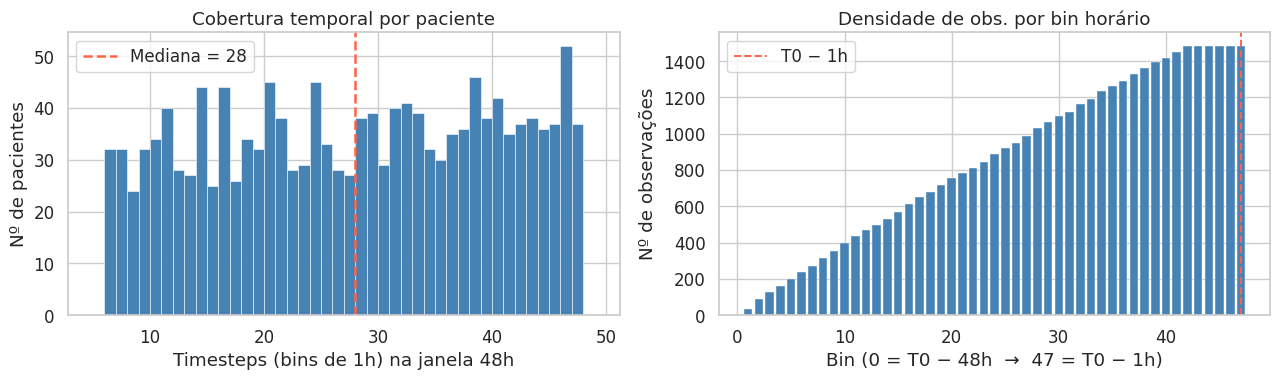

→ Bins próximos ao T0 têm mais observações (monitoramento intensifica pré-intervenção).


In [49]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histograma de timesteps por paciente
axes[0].hist(bins_per_patient, bins=range(5, 50), edgecolor='white', lw=0.4, color='steelblue')
axes[0].axvline(bins_per_patient.median(), color='tomato', lw=1.8, ls='--',
                label=f'Mediana = {bins_per_patient.median():.0f}')
axes[0].set(xlabel='Timesteps (bins de 1h) na janela 48h',
            ylabel='Nº de pacientes',
            title='Cobertura temporal por paciente')
axes[0].legend()

# Densidade de observações por bin
bin_counts = raw_win.groupby('bin').size()
axes[1].bar(bin_counts.index, bin_counts.values, color='steelblue', edgecolor='white', lw=0.3)
axes[1].set(xlabel='Bin (0 = T0 − 48h  →  47 = T0 − 1h)',
            ylabel='Nº de observações',
            title='Densidade de obs. por bin horário')
axes[1].axvline(47, color='tomato', ls='--', lw=1.4, label='T0 − 1h')
axes[1].legend()

plt.tight_layout()
plt.show()
print('→ Bins próximos ao T0 têm mais observações (monitoramento intensifica pré-intervenção).')

---
## 7. Estatísticas descritivas — elegíveis, janela 48h

In [50]:
raw_win[VITALS].describe().round(3)

,hemoglobin,lactate,creatinine,platelets,heart_rate,mbp,resp_rate,spo2,sofa,any_vasopressor,ventilation_on
count,40610.000,40610.000,40610.000,40610.000,40610.000,40610.000,40610.000,40610.000,39767.000,40610.000,40610.000
mean,9.701,1.781,1.603,210.884,89.266,75.820,20.229,97.119,5.194,0.018,0.482
std,1.713,1.236,1.607,126.761,18.604,13.826,5.664,3.208,3.569,0.049,0.495
min,8.000,0.467,0.100,5.000,41.000,7.000,2.792,7.000,0.000,0.000,0.000
25%,8.500,1.200,0.800,128.333,75.500,66.250,16.000,95.667,2.000,0.000,0.000
50%,9.100,1.300,1.000,194.000,88.000,74.000,19.667,97.917,4.917,0.000,0.000
75%,10.200,2.000,1.800,253.000,101.583,83.667,24.000,99.417,7.000,0.000,1.000
max,16.700,20.300,21.800,2001.000,194.833,265.583,68.000,100.000,21.000,1.000,1.000


In [51]:
# Descrição mais legível com renaming
desc = raw_win[VITALS].describe().round(2)
desc.columns = [VITALS_LABELS[c] for c in VITALS]
desc

,Hemoglobina (g/dL),Lactato (mmol/L),Creatinina (mg/dL),Plaquetas (×10³/µL),Frequência Cardíaca (bpm),PAM (mmHg),FR (rpm),SpO₂ (%),SOFA Score,Vasopressor (binário),Ventilação Mecânica (binário)
count,40610.000,40610.000,40610.000,40610.000,40610.000,40610.000,40610.000,40610.000,39767.000,40610.000,40610.000
mean,9.700,1.780,1.600,210.880,89.270,75.820,20.230,97.120,5.190,0.020,0.480
std,1.710,1.240,1.610,126.760,18.600,13.830,5.660,3.210,3.570,0.050,0.500
min,8.000,0.470,0.100,5.000,41.000,7.000,2.790,7.000,0.000,0.000,0.000
25%,8.500,1.200,0.800,128.330,75.500,66.250,16.000,95.670,2.000,0.000,0.000
50%,9.100,1.300,1.000,194.000,88.000,74.000,19.670,97.920,4.920,0.000,0.000
75%,10.200,2.000,1.800,253.000,101.580,83.670,24.000,99.420,7.000,0.000,1.000
max,16.700,20.300,21.800,2001.000,194.830,265.580,68.000,100.000,21.000,1.000,1.000


---
## 8. Distribuições dos sinais vitais

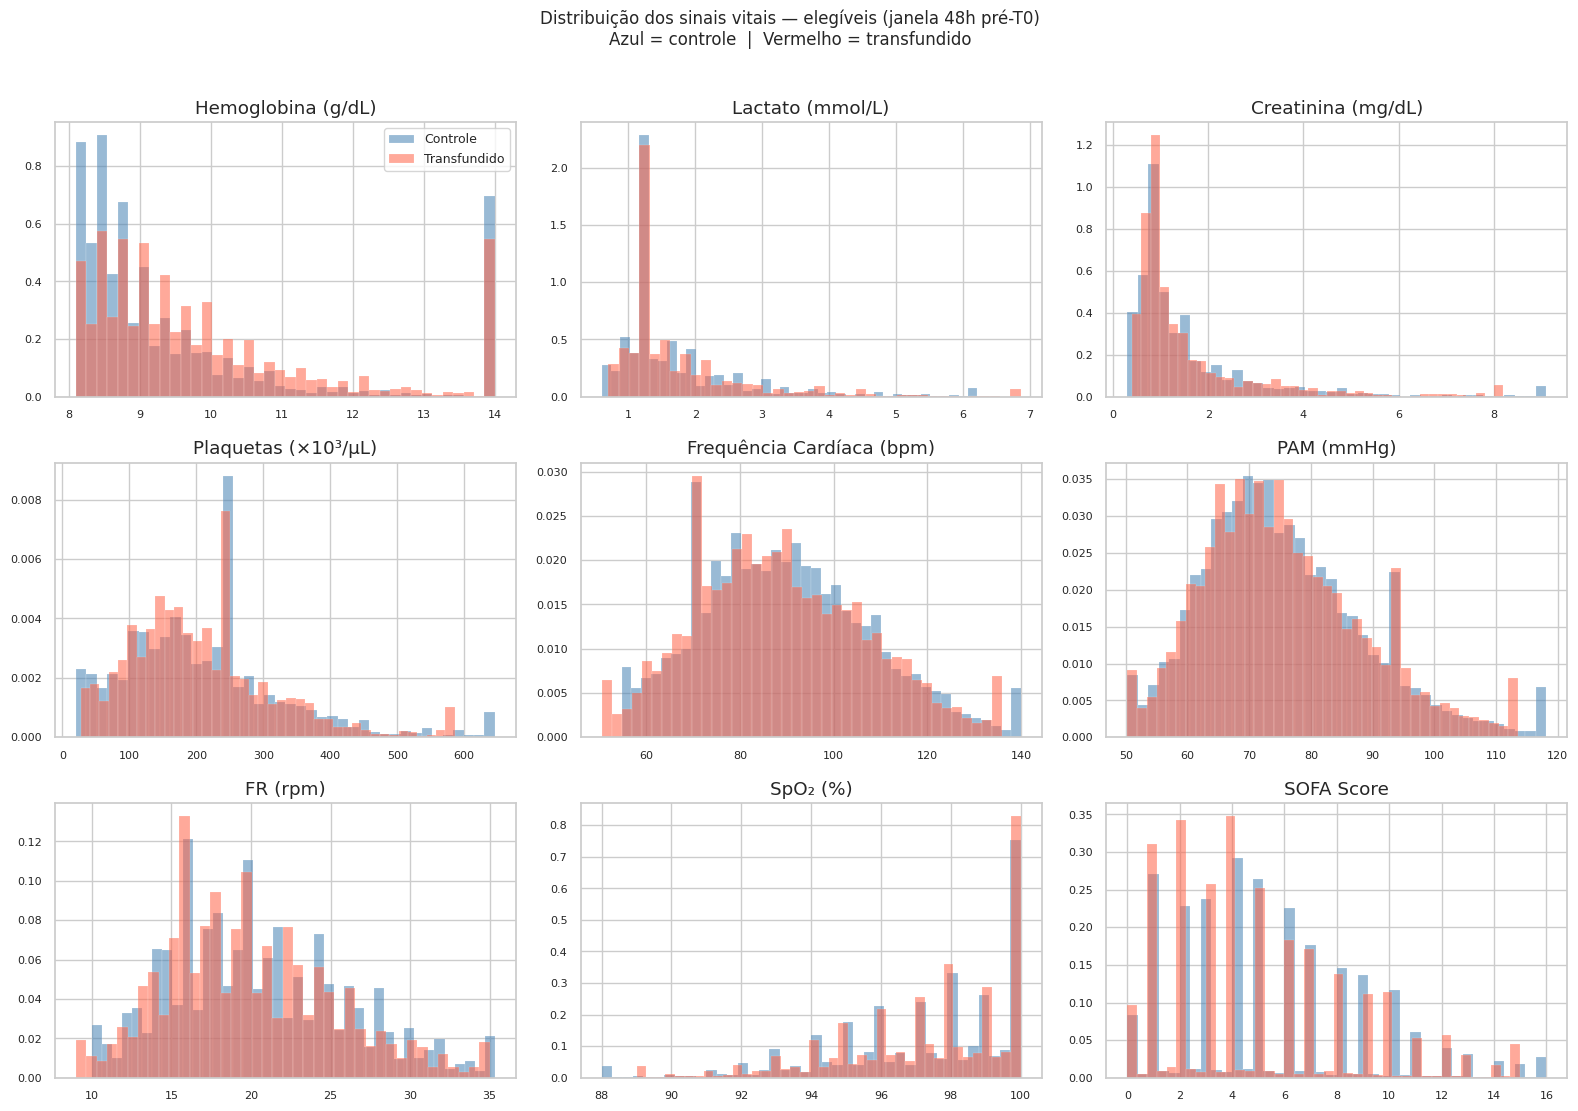

In [52]:
# Adiciona label de tratamento para colorir
raw_win = raw_win.merge(treat[['stay_id', 'transfused']], on='stay_id', how='left')

continuous_vitals = ['hemoglobin', 'lactate', 'creatinine', 'platelets',
                     'heart_rate', 'mbp', 'resp_rate', 'spo2', 'sofa']

fig, axes = plt.subplots(3, 3, figsize=(16, 11))
axes = axes.flatten()

palette = {0: 'steelblue', 1: 'tomato'}
labels  = {0: 'Controle', 1: 'Transfundido'}

for ax, col in zip(axes, continuous_vitals):
    for grp, color in palette.items():
        vals = raw_win[raw_win['transfused'] == grp][col].dropna()
        # clip outliers para visualização
        p1, p99 = vals.quantile(0.01), vals.quantile(0.99)
        vals_clip = vals.clip(p1, p99)
        ax.hist(vals_clip, bins=40, alpha=0.55, color=color,
                edgecolor='white', lw=0.2, density=True, label=labels[grp])
    ax.set(title=VITALS_LABELS[col], xlabel='', ylabel='')
    ax.tick_params(labelsize=8)

axes[0].legend(fontsize=9, loc='upper right')
fig.suptitle('Distribuição dos sinais vitais — elegíveis (janela 48h pré-T0)\nAzul = controle  |  Vermelho = transfundido',
             y=1.01, fontsize=12)
plt.tight_layout()
plt.show()

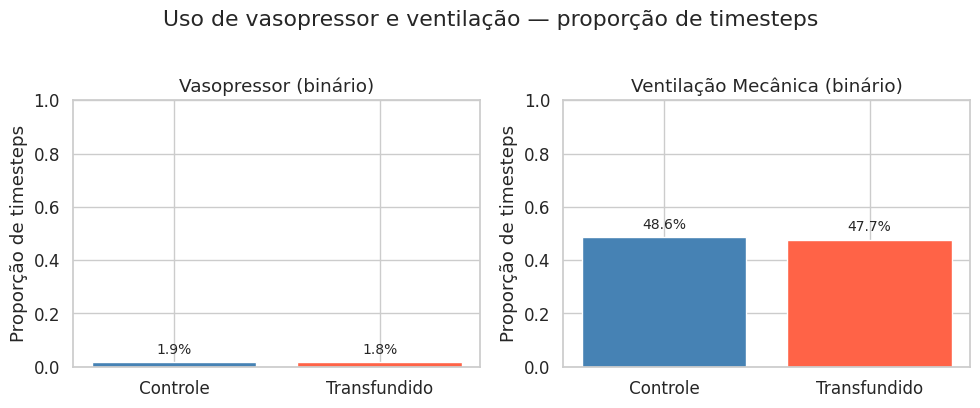

In [53]:
# Variáveis binárias: proporção de uso
binary_vitals = ['any_vasopressor', 'ventilation_on']

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, col in zip(axes, binary_vitals):
    props = (raw_win.groupby('transfused')[col]
                    .mean()
                    .rename({0: 'Controle', 1: 'Transfundido'}))
    bars = ax.bar(props.index, props.values,
                  color=['steelblue', 'tomato'], edgecolor='white')
    ax.set(title=VITALS_LABELS[col],
           ylabel='Proporção de timesteps',
           ylim=(0, 1))
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{bar.get_height():.1%}', ha='center', va='bottom', fontsize=10)

plt.suptitle('Uso de vasopressor e ventilação — proporção de timesteps', y=1.02)
plt.tight_layout()
plt.show()

---
## 9. Trajetória temporal dos sinais vitais

Mediana por bin horário, separada por grupo (tratado vs controle).

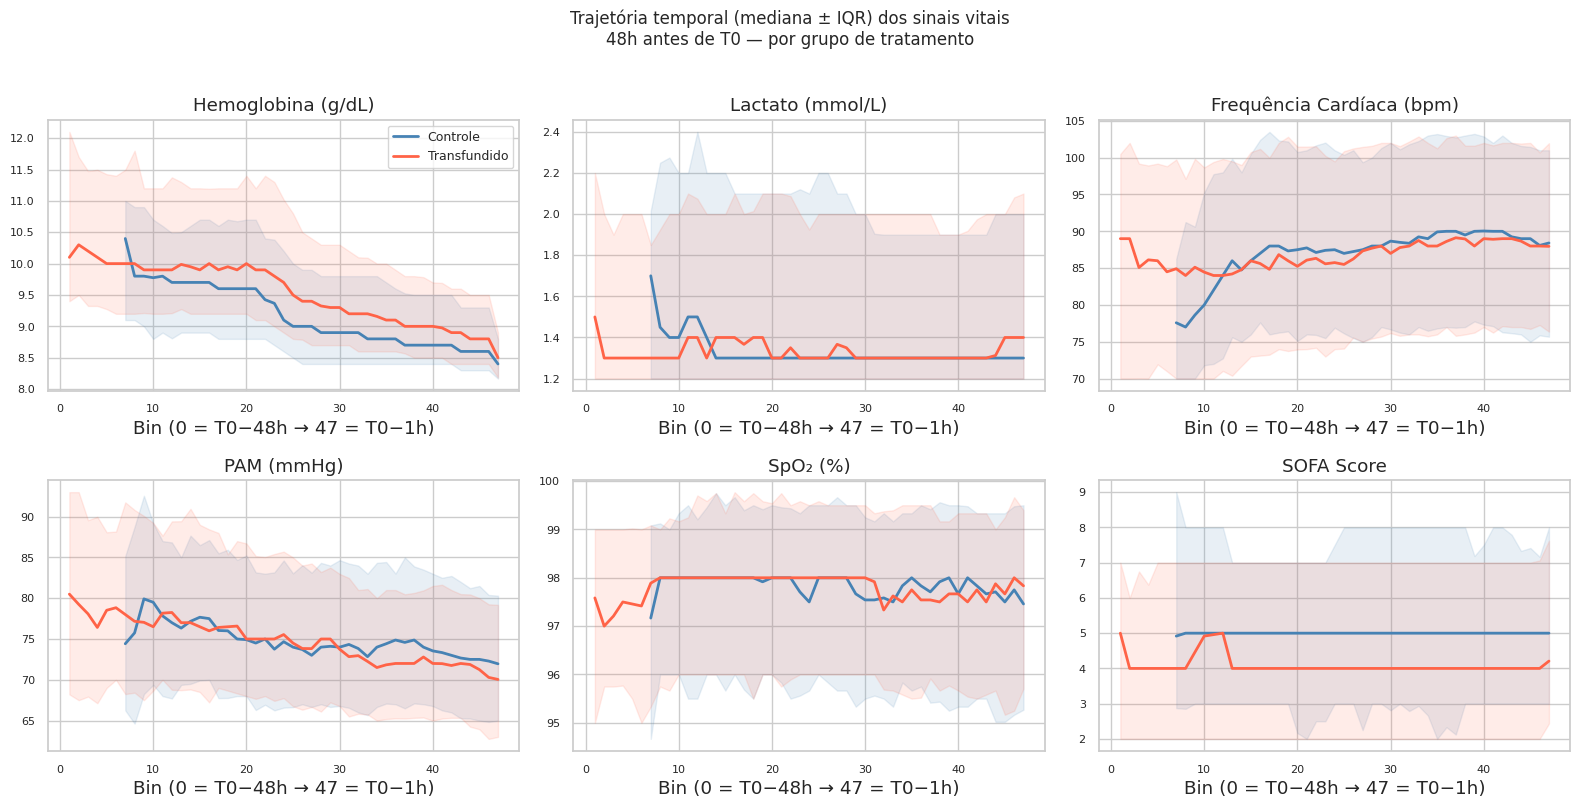

→ Hemoglobina cai progressivamente até T0 em ambos os grupos, como esperado.
→ Lactato e SOFA ligeiramente mais elevados nos transfundidos (confundimento por indicação).


In [54]:
temporal_vitals = ['hemoglobin', 'lactate', 'heart_rate', 'mbp', 'spo2', 'sofa']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for ax, col in zip(axes, temporal_vitals):
    for grp, color, label in [(0, 'steelblue', 'Controle'), (1, 'tomato', 'Transfundido')]:
        subset = raw_win[raw_win['transfused'] == grp]
        med = subset.groupby('bin')[col].median()
        q25 = subset.groupby('bin')[col].quantile(0.25)
        q75 = subset.groupby('bin')[col].quantile(0.75)
        ax.plot(med.index, med.values, color=color, lw=2, label=label)
        ax.fill_between(med.index, q25.values, q75.values, color=color, alpha=0.12)

    ax.set(title=VITALS_LABELS[col],
           xlabel='Bin (0 = T0−48h → 47 = T0−1h)',
           ylabel='')
    ax.tick_params(labelsize=8)

axes[0].legend(fontsize=9)
fig.suptitle('Trajetória temporal (mediana ± IQR) dos sinais vitais\n48h antes de T0 — por grupo de tratamento',
             y=1.01, fontsize=12)
plt.tight_layout()
plt.show()
print('→ Hemoglobina cai progressivamente até T0 em ambos os grupos, como esperado.')
print('→ Lactato e SOFA ligeiramente mais elevados nos transfundidos (confundimento por indicação).')

---
## 10. Hemoglobina em T0 por desfecho e tratamento

/tmp/ipykernel_659652/2459873147.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=hb_last, x='Grupo', y='hemoglobin',


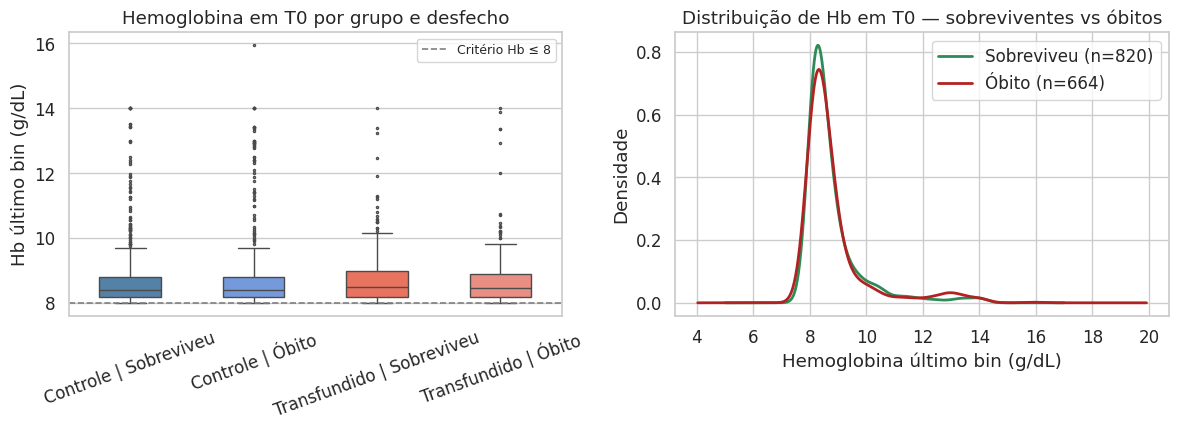

                                Mediana  Média    DP
transfused   mortality_anytime                      
Controle     Controle             8.400  8.790 1.140
             Transfundido         8.400  8.900 1.360
Transfundido Controle             8.500  8.760 0.880
             Transfundido         8.470  8.740 0.960


In [55]:
# Hb no último bin válido por paciente (proxy Hb em T0)
hb_last = (raw_win.sort_values('bin')
                  .groupby('stay_id')[['hemoglobin','transfused']]
                  .last()
                  .reset_index())
hb_last = hb_last.merge(trial, on='stay_id')

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Box plot Hb por tratamento × desfecho
hb_last['Grupo'] = hb_last.apply(
    lambda r: ('Transfundido' if r.transfused else 'Controle') +
              ' | ' + ('Óbito' if r.mortality_anytime else 'Sobreviveu'),
    axis=1)
order = ['Controle | Sobreviveu', 'Controle | Óbito',
         'Transfundido | Sobreviveu', 'Transfundido | Óbito']
palette_box = ['steelblue', 'cornflowerblue', 'tomato', 'salmon']

sns.boxplot(data=hb_last, x='Grupo', y='hemoglobin',
            order=order, palette=palette_box, ax=axes[0],
            width=0.5, fliersize=1.5)
axes[0].set(xlabel='', ylabel='Hb último bin (g/dL)',
            title='Hemoglobina em T0 por grupo e desfecho')
axes[0].tick_params(axis='x', rotation=20)
axes[0].axhline(8, ls='--', color='gray', lw=1.2, label='Critério Hb ≤ 8')
axes[0].legend(fontsize=9)

# KDE Hb por sobrevivência
for mort, color, label in [(0, 'seagreen', 'Sobreviveu'), (1, 'firebrick', 'Óbito')]:
    vals = hb_last[hb_last['mortality_anytime'] == mort]['hemoglobin'].dropna()
    vals.plot.kde(ax=axes[1], color=color, lw=2, label=f'{label} (n={len(vals)})')
axes[1].set(xlabel='Hemoglobina último bin (g/dL)',
            ylabel='Densidade',
            title='Distribuição de Hb em T0 — sobreviventes vs óbitos')
axes[1].legend()

plt.tight_layout()
plt.show()

print(hb_last.groupby(['transfused','mortality_anytime'])['hemoglobin']
             .agg(['median','mean','std'])
             .rename(index={0:'Controle', 1:'Transfundido'},
                     columns={'median':'Mediana','mean':'Média','std':'DP'})
             .round(2))

---
## 11. Grupos AIPW

In [56]:
g = (groups[['stay_id','B1','B2','M1','M2','M3']]
          .merge(treat[['stay_id','transfused']], on='stay_id')
          .merge(trial, on='stay_id'))

group_cols = ['B1', 'B2', 'M1', 'M2', 'M3']
group_labels = {
    'B1': 'B1 — Benefício (ATE ≈ −0.31)',
    'B2': 'B2 — Benefício (ATE ≈ −0.35)',
    'M1': 'M1 — Malefício (ATE ≈ +0.24)',
    'M2': 'M2 — Malefício (ATE ≈ +0.45)',
    'M3': 'M3 — Malefício (ATE ≈ +0.31)',
}

# Sumário dos grupos
summary = []
for col in group_cols:
    mask = g[col] == 1
    summary.append({
        'Grupo': group_labels[col],
        'N': int(mask.sum()),
        '% total': f"{mask.sum()/len(g)*100:.1f}%",
        '% transfundido': f"{g[mask]['transfused'].mean()*100:.1f}%",
        'Mortalidade': f"{g[mask]['mortality_anytime'].mean()*100:.1f}%",
    })

pd.DataFrame(summary).set_index('Grupo')

,N,% total,% transfundido,Mortalidade
Grupo,,,,
B1 — Benefício (ATE ≈ −0.31),151,10.2%,30.5%,39.7%
B2 — Benefício (ATE ≈ −0.35),117,7.9%,29.9%,40.2%
M1 — Malefício (ATE ≈ +0.24),328,22.1%,43.0%,40.2%
M2 — Malefício (ATE ≈ +0.45),109,7.3%,47.7%,56.9%
M3 — Malefício (ATE ≈ +0.31),219,14.8%,16.9%,49.8%


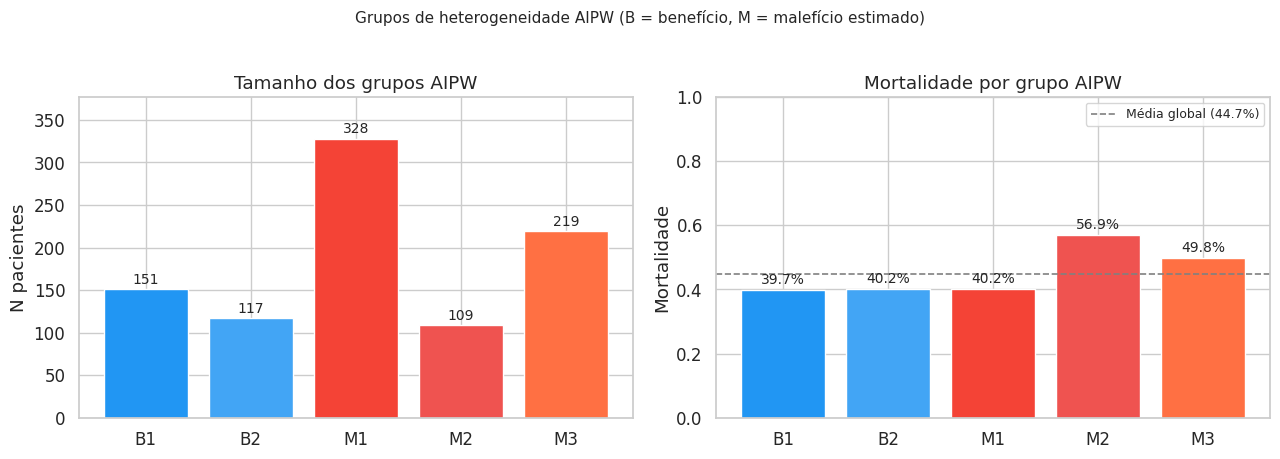

→ Grupos B1/B2 têm mortalidade mais baixa — pacientes que se beneficiaram da transfusão.
→ Grupos M1/M2/M3 têm mortalidade mais alta — possível confundimento por indicação.


In [57]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Tamanhos dos grupos
sizes = [int(g[c].sum()) for c in group_cols]
colors_grp = ['#2196F3','#42A5F5','#F44336','#EF5350','#FF7043']
bars = axes[0].bar(group_cols, sizes, color=colors_grp, edgecolor='white')
for bar, n in zip(bars, sizes):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                 str(n), ha='center', va='bottom', fontsize=10)
axes[0].set(ylabel='N pacientes', title='Tamanho dos grupos AIPW',
            ylim=(0, max(sizes) * 1.15))

# Mortalidade por grupo
mort_grp = [g[g[c]==1]['mortality_anytime'].mean() for c in group_cols]
bars2 = axes[1].bar(group_cols, mort_grp, color=colors_grp, edgecolor='white')
for bar, v in zip(bars2, mort_grp):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{v:.1%}', ha='center', va='bottom', fontsize=10)
axes[1].axhline(0.447, ls='--', color='gray', lw=1.2, label='Média global (44.7%)')
axes[1].set(ylabel='Mortalidade', title='Mortalidade por grupo AIPW',
            ylim=(0, 1))
axes[1].legend(fontsize=9)

plt.suptitle('Grupos de heterogeneidade AIPW (B = benefício, M = malefício estimado)',
             y=1.02, fontsize=11)
plt.tight_layout()
plt.show()
print('→ Grupos B1/B2 têm mortalidade mais baixa — pacientes que se beneficiaram da transfusão.')
print('→ Grupos M1/M2/M3 têm mortalidade mais alta — possível confundimento por indicação.')

---
# Parte 2 — Preparação dos Dados para o VCIP

---
## 14. Construção do Tensor Temporal

Converte o `raw_win` (tabela longa: 1 linha por timestep) em tensores NumPy alinhados por paciente, prontos para o modelo VCIP:

| Tensor | Shape | Conteúdo |
|---|---|---|
| **X** | `(N, 48, 11)` | Sinais vitais/labs, pós-ffill e z-score |
| **obs_mask** | `(N, 48)` | `1` = bin tem medição original; `0` = sem dado |
| **V** | `(N, 8)` | Age, sex, BMI, B1–M3 |
| **A** | `(N,)` | Intervenção em T0: `1` = transfundido |
| **Y** | `(N,)` | Desfecho: `mortality_anytime` (Bernoulli) |

**Pipeline:** grid completo (1.484 × 48) → forward-fill por paciente → features estáticas → normalização pós-split.

In [58]:
# ── Parâmetros ────────────────────────────────────────────────────────────────
MAX_SEQ = 48    # timesteps de 1h na janela pré-T0
TAU     = 4     # horizonte de predição padrão (4h) — usado a partir da Seção 18

stay_ids_arr = treat['stay_id'].values      # (1484,) — ordem fixa para todos os tensores
n_patients   = len(stay_ids_arr)

# ── 1. Grid completo (stay_id × bin) com todos os 1.484 × 48 pares ───────────
full_idx = pd.MultiIndex.from_product(
    [stay_ids_arr, range(MAX_SEQ)], names=['stay_id', 'bin'])

# obs_mask: 1 onde raw_win tem linha real (antes do ffill)
obs_mask = (raw_win.groupby(['stay_id', 'bin'])[VITALS[0]]
                   .count()               # 0 se sem linha; ≥1 se existe
                   .gt(0)
                   .reindex(full_idx, fill_value=False)
                   .values
                   .reshape(n_patients, MAX_SEQ)
                   .astype(np.float32))   # (N, 48)

# ── 2. Tensor X com forward-fill por paciente ─────────────────────────────────
# groupby → mean (resolve duplicatas improváveis), reindex → ffill → reshape
grid = (raw_win.groupby(['stay_id', 'bin'])[VITALS]
               .mean()
               .reindex(full_idx)
               .groupby(level='stay_id')
               .ffill()
               .reset_index())

X_raw = (grid[VITALS].values
                     .reshape(n_patients, MAX_SEQ, len(VITALS))
                     .astype(np.float32))   # (N, 48, 11)

# ── Diagnóstico ───────────────────────────────────────────────────────────────
coverage = obs_mask.sum(axis=1)
print(f'X_raw    : {X_raw.shape}   (pacientes × timesteps × vitais)')
print(f'obs_mask : {obs_mask.shape}')
print(f'\nCobertura por paciente (bins observados):  '
      f'mediana={np.median(coverage):.0f}  '
      f'p25={np.percentile(coverage,25):.0f}  '
      f'p75={np.percentile(coverage,75):.0f}  '
      f'min={int(coverage.min())}  max={int(coverage.max())}')
print(f'\nNaN pós-ffill por variável:')
for j, v in enumerate(VITALS):
    n   = int(np.isnan(X_raw[:, :, j]).sum())
    pct = n / X_raw[:, :, j].size * 100
    bar = '▓' * int(pct / 2)
    print(f'  {v:20s}: {n:6,}  ({pct:4.1f}%)  {bar}')

X_raw    : (1484, 48, 11)   (pacientes × timesteps × vitais)
obs_mask : (1484, 48)

Cobertura por paciente (bins observados):  mediana=28  p25=17  p75=38  min=6  max=47

NaN pós-ffill por variável:
  hemoglobin          : 30,622  (43.0%)  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  lactate             : 30,622  (43.0%)  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  creatinine          : 30,622  (43.0%)  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  platelets           : 30,622  (43.0%)  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  heart_rate          : 30,622  (43.0%)  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  mbp                 : 30,622  (43.0%)  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  resp_rate           : 30,622  (43.0%)  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  spo2                : 30,622  (43.0%)  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  sofa                : 31,465  (44.2%)  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  any_vasopressor     : 30,622  (43.0%)  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  ventilation_on      : 30,622  (43.0%)  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓


In [59]:
# ── Features estáticas (V), intervenção (A) e desfecho (Y) ───────────────────
# age, sex, bmi são constantes por paciente — pegamos a 1ª linha do raw_win
static_base = raw_win.groupby('stay_id')[['age', 'sex', 'bmi']].first().reset_index()
groups_sub  = groups[['stay_id', 'B1', 'B2', 'M1', 'M2', 'M3']]
outcomes    = treat[['stay_id', 'transfused']].merge(trial, on='stay_id')

# Alinha na ordem fixa de stay_ids_arr
static_df = (pd.DataFrame({'stay_id': stay_ids_arr})
             .merge(static_base, on='stay_id', how='left')
             .merge(groups_sub,  on='stay_id', how='left')
             .merge(outcomes,    on='stay_id', how='left'))

static_df['sex_bin'] = (static_df['sex'] == 'M').astype(float)

STATIC_COLS = ['age', 'sex_bin', 'bmi', 'B1', 'B2', 'M1', 'M2', 'M3']
V_raw = static_df[STATIC_COLS].values.astype(np.float32)   # (N, 8)
A     = static_df['transfused'].values.astype(np.float32)  # (N,) — intervenção em T0
Y     = static_df['mortality_anytime'].values.astype(np.float32)  # (N,) — desfecho

# ── Sumário dos tensores (pré-normalização) ───────────────────────────────────
print('Tensores gerados (pré-normalização):')
print(f'  X_raw    {X_raw.shape}  vitais temporais    '
      f'NaN: {np.isnan(X_raw).sum():,}')
print(f'  obs_mask {obs_mask.shape}  bins com medição real')
print(f'  V_raw    {V_raw.shape}   features estáticas  '
      f'NaN: {np.isnan(V_raw).sum():,}  '
      f'(bmi: {np.isnan(V_raw[:, STATIC_COLS.index("bmi")]).sum()} pacientes)')
print(f'  A        {A.shape}     intervenção em T0  | transfundidos: {A.mean():.1%}')
print(f'  Y        {Y.shape}     desfecho           | mortalidade:   {Y.mean():.1%}')

Tensores gerados (pré-normalização):
  X_raw    (1484, 48, 11)  vitais temporais    NaN: 337,685
  obs_mask (1484, 48)  bins com medição real
  V_raw    (1484, 8)   features estáticas  NaN: 397  (bmi: 397 pacientes)
  A        (1484,)     intervenção em T0  | transfundidos: 34.1%
  Y        (1484,)     desfecho           | mortalidade:   44.7%


---
## 15. Divisão Treino / Val / Teste

Split por **`subject_id`**  para garantir que internações do mesmo paciente não apareçam em splits diferentes. Proporções: **70 % treino / 15 % val / 15 % teste**, estratificadas por `transfused`.

A normalização z-score é ajustada **exclusivamente no treino** e aplicada ao val/teste sem re-fit. O NaN residual após forward-fill é preenchido com a mediana do treino por variável.

In [60]:
from sklearn.model_selection import train_test_split

# ── Split por subject_id ───────────────────────────────────────────────────────
# Agrupa stay_ids por subject_id (um paciente pode ter múltiplas internações)
subj_df = (pd.DataFrame({'stay_id': stay_ids_arr})
           .merge(treat[['stay_id', 'subject_id', 'transfused']], on='stay_id'))

by_subj = (subj_df.groupby('subject_id')
                  .agg(transfused=('transfused', 'max'),
                       stay_ids=('stay_id', list))
                  .reset_index())

# 70 / 15 / 15, estratificado por transfused
s_train, s_temp = train_test_split(by_subj, test_size=0.30,
                                    stratify=by_subj['transfused'], random_state=42)
s_val, s_test   = train_test_split(s_temp,  test_size=0.50,
                                    stratify=s_temp['transfused'],  random_state=42)

# Mapeia de volta para índices posicionais no array stay_ids_arr
sid2pos = {sid: i for i, sid in enumerate(stay_ids_arr)}
def to_pos(df):
    return np.array(sorted(sid2pos[s] for row in df['stay_ids'] for s in row))

idx_train = to_pos(s_train)
idx_val   = to_pos(s_val)
idx_test  = to_pos(s_test)

# Garante ausência de sobreposição
assert not (set(idx_train) & set(idx_val)),  'Vazamento treino↔val!'
assert not (set(idx_train) & set(idx_test)), 'Vazamento treino↔teste!'
assert not (set(idx_val)   & set(idx_test)), 'Vazamento val↔teste!'

print('Split por subject_id (estratificado por transfused):')
for name, idx in [('Treino', idx_train), ('Val', idx_val), ('Teste', idx_test)]:
    print(f'  {name:6s}: {len(idx):4d} pacientes  ({len(idx)/n_patients:.1%})'
          f'  | transfundidos: {A[idx].mean():.1%}'
          f'  | mortalidade: {Y[idx].mean():.1%}')

Split por subject_id (estratificado por transfused):
  Treino: 1038 pacientes  (69.9%)  | transfundidos: 34.1%  | mortalidade: 43.4%
  Val   :  223 pacientes  (15.0%)  | transfundidos: 34.1%  | mortalidade: 50.2%
  Teste :  223 pacientes  (15.0%)  | transfundidos: 34.1%  | mortalidade: 45.7%


NaN em X pós-normalização : 0
NaN em V pós-normalização : 0

Z-score de X (treino deve ter média≈0, std≈1):
  hemoglobin            média=+0.000  std=1.000
  lactate               média=+0.000  std=1.000
  creatinine            média=+0.000  std=1.000
  platelets             média=-0.000  std=1.000
  heart_rate            média=+0.000  std=1.000
  mbp                   média=-0.000  std=1.000
  resp_rate             média=+0.000  std=1.000
  spo2                  média=-0.000  std=1.000
  sofa                  média=+0.000  std=1.000
  any_vasopressor       média=-0.000  std=1.000
  ventilation_on        média=-0.000  std=1.000


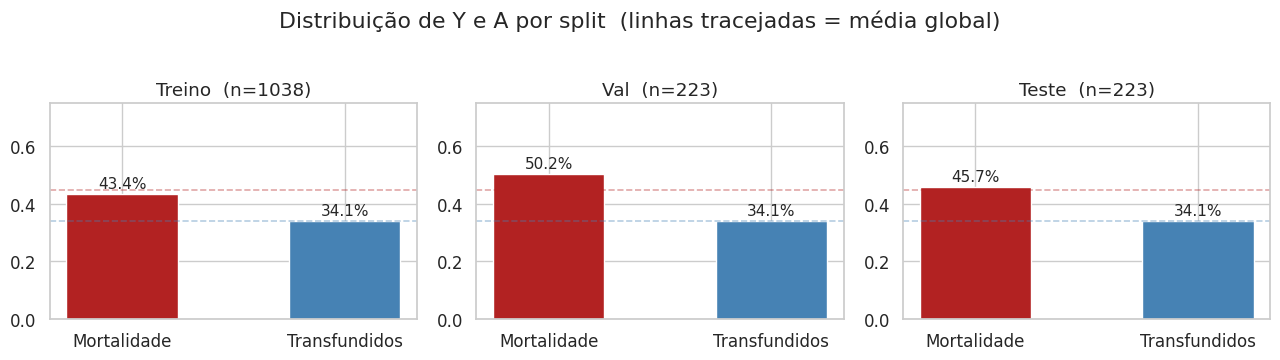


Tensores salvos → vcip_tensors.pkl  (3422 KB)
Próximo passo: Seção 16 — configuração e instanciação do modelo VCIP.


In [61]:
from sklearn.preprocessing import StandardScaler
import pickle

# ── Cópias mutáveis ───────────────────────────────────────────────────────────
X = X_raw.copy()
V = V_raw.copy()

# ── NaN residual em X → mediana do treino por variável ───────────────────────
train_med_X = np.nanmedian(X[idx_train].reshape(-1, len(VITALS)), axis=0)
for j in range(len(VITALS)):
    X[:, :, j] = np.where(np.isnan(X[:, :, j]), train_med_X[j], X[:, :, j])

# ── Z-score de X: fit exclusivamente no treino ───────────────────────────────
scaler_X = StandardScaler()
scaler_X.fit(X[idx_train].reshape(-1, len(VITALS)))
X = (scaler_X.transform(X.reshape(-1, len(VITALS)))
             .reshape(n_patients, MAX_SEQ, len(VITALS))
             .astype(np.float32))

# ── BMI em V → mediana do treino; z-score de age e bmi ───────────────────────
bmi_i  = STATIC_COLS.index('bmi')
cont_i = [STATIC_COLS.index('age'), bmi_i]
V[np.isnan(V[:, bmi_i]), bmi_i] = np.nanmedian(V[idx_train, bmi_i])
scaler_V = StandardScaler()
scaler_V.fit(V[idx_train][:, cont_i])
V[:, cont_i] = scaler_V.transform(V[:, cont_i]).astype(np.float32)

print(f'NaN em X pós-normalização : {np.isnan(X).sum()}')
print(f'NaN em V pós-normalização : {np.isnan(V).sum()}')
print(f'\nZ-score de X (treino deve ter média≈0, std≈1):')
X_tr = X[idx_train].reshape(-1, len(VITALS))
for j, v in enumerate(VITALS):
    print(f'  {v:20s}  média={X_tr[:,j].mean():+.3f}  std={X_tr[:,j].std():.3f}')

# ── Verificação visual: splits devem ter distribuições similares ─────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
for ax, (name, idx) in zip(axes, [('Treino', idx_train), ('Val', idx_val), ('Teste', idx_test)]):
    vals = [Y[idx].mean(), A[idx].mean()]
    bars = ax.bar(['Mortalidade', 'Transfundidos'], vals,
                  color=['firebrick', 'steelblue'], edgecolor='white', width=0.5)
    ax.set(title=f'{name}  (n={len(idx)})', ylim=(0, 0.75))
    ax.axhline(Y.mean(), color='firebrick', ls='--', lw=1.2, alpha=0.4)
    ax.axhline(A.mean(), color='steelblue', ls='--', lw=1.2, alpha=0.4)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{bar.get_height():.1%}', ha='center', fontsize=11)
plt.suptitle('Distribuição de Y e A por split  (linhas tracejadas = média global)', y=1.03)
plt.tight_layout()
plt.show()

# ── Salvamento ────────────────────────────────────────────────────────────────
tensors = dict(
    X=X, obs_mask=obs_mask, V=V, A=A, Y=Y,
    stay_ids=stay_ids_arr,
    idx_train=idx_train, idx_val=idx_val, idx_test=idx_test,
    scaler_X=scaler_X, scaler_V=scaler_V, train_med_X=train_med_X,
    vitals=VITALS, static_cols=STATIC_COLS,
)
out_path = Path('vcip_tensors.pkl')
with open(out_path, 'wb') as f:
    pickle.dump(tensors, f)
print(f'\nTensores salvos → {out_path}  ({out_path.stat().st_size/1024:.0f} KB)')
print('Próximo passo: Seção 16 — configuração e instanciação do modelo VCIP.')

---
# Parte 3 — Modelo VCIP

## 16. Configuração e Instanciação

Todo o pipeline VCIP parte de um único objeto `cfg` (OmegaConf) que centraliza dimensões, arquitetura e hiperparâmetros. Esta seção:

1. **Imports** — adiciona `VCIP-ICML` ao `sys.path` e importa as classes necessárias
2. **Config** — define e exibe todos os parâmetros (dataset, modelo, ELBO, treino)
3. **DatasetCollection** — envolve os tensores já normalizados do `vcip_tensors.pkl` (Seções 14-15) nos objetos PyTorch que o `VAEModel` espera
4. **Modelo** — instancia o `VAEModel`, conta parâmetros por componente

> **Por que não usar `MIMIC4MortalityDatasetCollection` diretamente:**  
> Ela leria os parquets de novo e refaria todo o preprocessing (~34s extras).  
> Pior: seu z-score interno usa todos os pacientes antes do split → **data leakage**.  
> As Seções 14-15 já fizeram o preprocessing corretamente (z-score fit só no treino).  
> Aqui apenas empacotamos esses tensores no formato que o `VAEModel` consome.

In [62]:
import sys
from pathlib import Path

# ── VCIP no sys.path ─────────────────────────────────────────────────────
VCIP_DIR = Path('VCIP').resolve()
if str(VCIP_DIR) not in sys.path:
    sys.path.insert(0, str(VCIP_DIR))

print(f'VCIP_DIR : {VCIP_DIR}')
print(f'Existe   : {VCIP_DIR.exists()}')

# ── Torch ─────────────────────────────────────────────────────────────────────
import torch
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'\nPyTorch  : {torch.__version__}')
print(f'Device   : {DEVICE}' +
      (f'  ({torch.cuda.get_device_name(0)})' if DEVICE == 'cuda' else '  (CPU)'))

# ── Imports do VCIP ───────────────────────────────────────────────────────────
# MIMIC4MortalityDataset: classe PyTorch Dataset (empacota tensores prontos)
# VAEModel: o modelo VCIP completo (generative + inference + auxiliary)
from src.data.mimic4_mortality.dataset import MIMIC4MortalityDataset
from src.models.vae_model import VAEModel

print('\nImports OK:')
print(f'  MIMIC4MortalityDataset  →  {MIMIC4MortalityDataset}')
print(f'  VAEModel                →  {VAEModel}')

VCIP_DIR : /home/alicia.chaves/vscode/causality/VCIP
Existe   : True

PyTorch  : 2.12.0+cu130
Device   : cuda  (NVIDIA GeForce RTX 2050)

Imports OK:
  MIMIC4MortalityDataset  →  <class 'src.data.mimic4_mortality.dataset.MIMIC4MortalityDataset'>
  VAEModel                →  <class 'src.models.vae_model.VAEModel'>


In [63]:
from omegaconf import OmegaConf

# ══════════════════════════════════════════════════════════════════════════════
# Config centralizada — espelha os YAML em configs/dataset/ e configs/model/
# Permite acesso tanto por atributo (cfg.exp.tau) quanto por chave (cfg['exp']['tau'])
# ══════════════════════════════════════════════════════════════════════════════
cfg = OmegaConf.create({

    # ── Dataset ──────────────────────────────────────────────────────────────
    'dataset': {
        'name':                'mimic4_mortality',
        # Dimensões dos dados
        'input_size':          11,    # X: Hb, Lact, Creat, Plaq, FC, PAM, FR, SpO2, SOFA, vaso, vent
        'treatment_size':       1,    # A: transfused (0/1)
        'output_size':          1,    # Y: mortality_anytime (0/1 → Bernoulli)
        'static_size':          8,    # V: age, sex_bin, bmi, B1, B2, M1, M2, M3
        # Modos de tratamento e desfecho
        'treatment_mode':      'multilabel',
        'output_mode':         'bernoulli',    # usa BCE em vez de MSE
        # Sequências temporais
        'max_seq_length':       48,            # bins de 1h → janela de 48h
        'min_seq_length':       25,
        'projection_horizon':    4,            # τ (horizonte do VCIP)
        # Flags
        'autoregressive':       True,
        'predict_X':            True,          # vitais como input do LSTM history
                                               # lambda_X=0 → sem penalidade de reconstrução
        # Split
        'split': {'val': 0.15, 'test': 0.15},
        'seed': 42,
        # Batch — lido por AuxiliaryModel.init_dataset_params()
        'val_batch_size':       64,
    },

    # ── Modelo ───────────────────────────────────────────────────────────────
    'model': {
        'name':   'vcip',
        'z_dim':  16,       # dimensão do espaço latente Z (estados fisiológicos latentes)
        'lr':      1e-3,    # lido por VAEModel.__init__ (line 31 de vae_model.py)
        # Encoder de inferência q_φ — vê Y_target durante o treino
        'inference': {
            'hidden_dim':        32,   # hidden size do LSTM de inferência
            'num_layers':         2,
            'hiddens_F_mu':      [32], # MLP para μ da posterior Z_t
            'hiddens_F_logvar':  [32], # MLP para log σ² da posterior Z_t
            'predict_y_history': [32], # MLP auxiliar de Y dado histórico
            'do':                True, # dropout ativo durante treino
        },
        # Modelo generativo p_θ — dinâmica fisiológica aprendida
        'generative': {
            'hidden_dim':                  32,  # hidden do LSTM generativo
            'treatment_hidden_dim':        16,  # hidden do LSTM de intervenção
            'num_layers':                   2,
            'entropy_lambda':               1.0,
            'hiddens_F_mu':               [32], # MLP para μ da transição Z_{t+1}
            'hiddens_F_logvar':           [32], # MLP para log σ² da transição
            'hiddens_decoder':            [32], # MLP decodificador Y | Z_{t+τ}
            'hidden_action_decoder':      [32], # p_θ(â | H_t) — sequência completa
            'hidden_action_decoder_step': [32], # p_θ(a_s | Z_s) — passo a passo
        },
        # Prior de intervenção — modelo do médico (componente da g-formula)
        'auxiliary': {
            'hidden_dim':   32,
            'num_layers':    2,
            'hiddens_G_y':  [32],
            'hiddens_G_x':  [32],
        },
    },

    # ── Experimento ──────────────────────────────────────────────────────────
    'exp': {
        'seed':           42,
        'device':         DEVICE,
        # Treino
        'batch_size':     128,
        'batch_size_val':  64,
        'epochs':         150,
        'patience':        25,    # early stopping (sem melhora no val loss)
        'lr':              1e-3,  # lido por AuxiliaryModel.init_exp_params()
        'weight_decay':    1e-5,
        'dropout':         0.2,
        'num_samples':     10,    # amostras Monte Carlo para estimativa do ELBO
        'weights_ema':     True,
        'beta':            0.999,
        # ── Lambdas do ELBO ──────────────────────────────────────────────────
        # ELBO = λ_reg·reg + λ_kl·KL + λ_step·step + λ_action·g_formula + λ_hy·aux_Y
        'lambda_X':        0.0,   # reconstrução de vitais (desligado — predict_X=True mas sem penalidade)
        'lambda_Y':        1.0,   # reconstrução do desfecho (BCE)
        'lambda_kl':       1.0,   # KL(q_φ(Z|·) || p_θ(Z|·)) — regularização do espaço latente
        'lambda_step':     0.1,   # transição Z_{s}→Z_{s+1} passo a passo
        'lambda_action':   1.0,   # g-formula: Σ log p_θ(a_s|Z_s) − log p_θ(â|H_t)
        'lambda_hy':       0.5,   # predição auxiliar de Y dado histórico
        'lambda_reg':      1.0,
        'beta_bound':    -10.0,   # clamp mínimo do log ELBO (estabilidade numérica)
        # Inferência / otimização de â* (Seção 18)
        'tau':              4,    # horizonte de otimização de â*
        'repeats':          5,    # repetições para GRP/RCS (Seção 19)
        # Flags de modo
        'remove_aux':      False, # se True, usa só reg_loss do último passo τ (sem efeito real no código atual)
        'test':            False, # se True, usa test_f na inferência em vez de val_f
        # Outros
        'load_best':       True,
        'val':             True,
        'log_dir':         'my_outputs/mimic4_mortality/vcip/42/',
    },
})

# ── Display da config ─────────────────────────────────────────────────────────
SEP = '─' * 60

print('DATASET')
print(SEP)
d = cfg.dataset
rows_d = [
    ('input_size   (X: vitais)',          d.input_size),
    ('treatment_size  (A)',                d.treatment_size),
    ('output_size  (Y: Bernoulli)',         d.output_size),
    ('static_size  (V: age,sex,bmi,grps)', d.static_size),
    ('max_seq_length  (bins de 1h)',        d.max_seq_length),
    ('projection_horizon  τ',              d.projection_horizon),
    ('val_batch_size',                     d.val_batch_size),
    ('output_mode',                        d.output_mode),
    ('predict_X',                          d.predict_X),
]
for k, v in rows_d:
    print(f'  {k:<42}: {v}')

print()
print('MODELO — arquitetura')
print(SEP)
m = cfg.model
rows_m = [
    ('z_dim  (espaço latente Z)',           m.z_dim),
    ('lr  (model.lr — VAEModel)',           m.lr),
    ('inference.hidden_dim  (LSTM q_φ)',    m.inference.hidden_dim),
    ('generative.hidden_dim  (LSTM p_θ)',   m.generative.hidden_dim),
    ('generative.treatment_hidden_dim',     m.generative.treatment_hidden_dim),
    ('num_layers  (LSTMs)',                 m.inference.num_layers),
]
for k, v in rows_m:
    print(f'  {k:<42}: {v}')

print()
print('TREINO')
print(SEP)
e = cfg.exp
rows_e = [
    ('batch_size / val_batch_size',  f'{e.batch_size} / {d.val_batch_size}'),
    ('epochs / patience',            f'{e.epochs} / {e.patience}'),
    ('lr / weight_decay',            f'{e.lr} / {e.weight_decay}'),
    ('dropout',                      e.dropout),
    ('num_samples  (Monte Carlo)',    e.num_samples),
    ('device',                       e.device),
]
for k, v in rows_e:
    print(f'  {k:<42}: {v}')

print()
print('ELBO — λ por componente')
print(SEP)
rows_l = [
    ('λ_X   reconstrução vitais  (desligado)',   e.lambda_X),
    ('λ_Y   reconstrução Y  (BCE)',              e.lambda_Y),
    ('λ_kl  KL divergence  q_φ || p_θ',         e.lambda_kl),
    ('λ_step  transição Z_s→Z_{s+1}',           e.lambda_step),
    ('λ_action  g-formula  (confundimento)',     e.lambda_action),
    ('λ_hy  predição auxiliar Y',               e.lambda_hy),
]
for k, v in rows_l:
    filled = '█' * int(float(v) * 10) if float(v) > 0 else '░ (desligado)'
    print(f'  {k:<42}: {str(v):>4}  {filled}')

# ── Dimensões derivadas ───────────────────────────────────────────────────────
lstm_in = d.input_size + d.static_size + d.treatment_size + d.output_size
print()
print('DIMENSÕES DERIVADAS')
print(SEP)
print(f'  LSTM history input  = X({d.input_size}) + V({d.static_size}) + A({d.treatment_size}) + Y({d.output_size}) = {lstm_in}')
print(f'  LSTM action input   = A({d.treatment_size})')
print(f'  Prior Z_t           ~ N(μ, σ²)  dim={m.z_dim}')
print(f'  Decoder output      = Y({d.output_size})  → Bernoulli(sigmoid(logit))')
print()
print('FLAGS ADICIONAIS')
print(SEP)
print(f'  remove_aux : {e.remove_aux}  (alterna qual reg_loss usar — sem efeito real no código atual)')
print(f'  test       : {e.test}  (False=usar val_f na inferência; True=usar test_f)')

DATASET
────────────────────────────────────────────────────────────
  input_size   (X: vitais)                  : 11
  treatment_size  (A)                       : 1
  output_size  (Y: Bernoulli)               : 1
  static_size  (V: age,sex,bmi,grps)        : 8
  max_seq_length  (bins de 1h)              : 48
  projection_horizon  τ                     : 4
  val_batch_size                            : 64
  output_mode                               : bernoulli
  predict_X                                 : True

MODELO — arquitetura
────────────────────────────────────────────────────────────
  z_dim  (espaço latente Z)                 : 16
  lr  (model.lr — VAEModel)                 : 0.001
  inference.hidden_dim  (LSTM q_φ)          : 32
  generative.hidden_dim  (LSTM p_θ)         : 32
  generative.treatment_hidden_dim           : 16
  num_layers  (LSTMs)                       : 2

TREINO
────────────────────────────────────────────────────────────
  batch_size / val_batch_size        

In [64]:
import pickle
import numpy as np

# ══════════════════════════════════════════════════════════════════════════════
# Constrói o dataset_collection a partir do vcip_tensors.pkl (Seções 14-15)
# ──────────────────────────────────────────────────────────────────────────────
# Os tensores já estão:
#   • z-score fit exclusivamente no treino  → sem data leakage
#   • split por subject_id estratificado    → sem leakage entre splits
#
# Por que NÃO usar MIMIC4MortalityDataset.__init__ diretamente:
#   Ele espera dict com chaves 'vitals_tensor', 'treatment', 'output', 'static',
#   enquanto CIPDataset precisa de 'vitals', 'prev_treatments', 'outputs', etc.
#   Usamos DatasetWrapper: objeto mínimo com .data + .simulate_output_after_actions.
# ══════════════════════════════════════════════════════════════════════════════

with open('vcip_tensors.pkl', 'rb') as f:
    T = pickle.load(f)

X        = T['X']           # (N, 48, 11)  z-scored, fit no treino
obs_mask = T['obs_mask']    # (N, 48)      1 = bin com medição original
V        = T['V']           # (N, 8)       features estáticas normalizadas
A        = T['A']           # (N,)         transfused 0/1
Y        = T['Y']           # (N,)         mortality_anytime 0/1
idx_train = T['idx_train']
idx_val   = T['idx_val']
idx_test  = T['idx_test']

N, T_len, n_vitals = X.shape   # 1484, 48, 11

# ── Tensor de tratamento: A na última bin observada, 0 no resto ───────────────
treatment_tensor = np.zeros((N, T_len, 1), dtype=np.float32)
for i in range(N):
    last = int(obs_mask[i].sum()) - 1
    last = max(0, min(last, T_len - 1))
    treatment_tensor[i, last, 0] = A[i]

# ── Tensor de desfecho: mortalidade repetida em todos os slots ───────────────
output_tensor = np.zeros((N, T_len, 1), dtype=np.float32)
output_tensor[:, :, 0] = Y[:, np.newaxis]

# ── Active entries: 1 nos bins com observação real ────────────────────────────
active_tensor = obs_mask[:, :, np.newaxis].astype(np.float32)   # (N, 48, 1)
seq_lengths   = np.maximum(obs_mask.sum(axis=1).astype(np.int32), 25)

# ── Parâmetros de escala (do scaler fit no treino) ────────────────────────────
scaling_params = {
    'output_means': np.array([0.0]),
    'output_stds':  np.array([1.0]),
    'vitals_means': T['scaler_X'].mean_,    # (11,) fit só no treino
    'vitals_stds':  T['scaler_X'].scale_,   # (11,) fit só no treino
}

# ── Monta o dict de arrays no contrato esperado por CIPDataset ───────────────
# auxiliary_model.build_representations() faz:
#   x = batch['vitals']                               # (B, h, 11)
#   x = torch.cat((x, batch['static_features']), -1)  # (B, h, 11+8)
#
# → static_features DEVE ser 3D: (n, T-1, 8) para que o cat funcione
#   np.tile repete o vetor V ao longo da dimensão temporal
T_seq = T_len - 1   # 47 timesteps após o [1:] de CIPDataset

def make_split(idx):
    n = len(idx)
    return {
        'sequence_lengths':   seq_lengths[idx] - 1,                              # (n,)
        'prev_treatments':    treatment_tensor[idx, :-1, :],                     # (n, 47, 1)
        'current_treatments': treatment_tensor[idx,  1:, :],                     # (n, 47, 1)
        # 3D: (n, 47, 8) — static_features repetidas em cada timestep
        'static_features':    np.tile(V[idx][:, np.newaxis, :], (1, T_seq, 1)), # (n, 47, 8)
        'prev_outputs':       output_tensor[idx, :-1, :],                        # (n, 47, 1)
        'outputs':            output_tensor[idx,  1:, :],                        # (n, 47, 1)
        'active_entries':     active_tensor[idx,  1:, :],                        # (n, 47, 1)
        'vitals':             X[idx,  1:, :],                                    # (n, 47, 11)
        'current_covariates': X[idx,  1:, :],                                    # (n, 47, 11)
        # scaling_params é um dict (len=4 ≠ N) → automaticamente excluído pelo CIPDataset
        'scaling_params':     scaling_params,
    }

# ── DatasetWrapper: contrato mínimo que VAEModel precisa ─────────────────────
class DatasetWrapper:
    """
    Wrapper leve: expõe .data (dict de arrays prontos para CIPDataset)
    e implementa simulate_output_after_actions para avaliação GRP/RCS.

    VAEModel acessa:
      • wrapper.data  → dict passado para CIPDataset
      • wrapper.simulate_output_after_actions(H_t, actions, scaling_params)
    """
    def __init__(self, data_dict: dict, subset_name: str):
        self.data        = data_dict
        self.subset_name = subset_name

    def __len__(self):
        return len(self.data['outputs'])

    def simulate_output_after_actions(self, H_t, actions, scaling_params=None):
        """Sem simulador fisiológico real — retorna zeros.
        Para GRP/RCS (Seção 19), o ranking é feito pelo ELBO do modelo."""
        return np.zeros((actions.shape[0], 1), dtype=np.float32)

train_ds = DatasetWrapper(make_split(idx_train), 'train')
val_ds   = DatasetWrapper(make_split(idx_val),   'val')
test_ds  = DatasetWrapper(make_split(idx_test),  'test')

# ── DatasetCollectionWrapper com a interface que VAEModel usa ─────────────────
class DatasetCollectionWrapper:
    """
    Expõe apenas o que VAEModel realmente acessa:
      .train_f / .val_f / .test_f  — DatasetWrapper com .data e __len__
      .train_scaling_params         — dict com vitals_means/stds
      .projection_horizon / .has_vitals / .autoregressive
    """
    def __init__(self, train_f, val_f, test_f, scaling_params):
        self.train_f                = train_f
        self.val_f                  = val_f
        self.test_f                 = test_f
        self.train_scaling_params   = scaling_params
        self.projection_horizon     = cfg.dataset.projection_horizon
        self.has_vitals             = True
        self.autoregressive         = cfg.dataset.autoregressive
        self.processed_data_encoder = True

dataset_collection = DatasetCollectionWrapper(train_ds, val_ds, test_ds, scaling_params)

# ── Diagnóstico ───────────────────────────────────────────────────────────────
SEP = '─' * 62
print('DatasetCollection — fonte: vcip_tensors.pkl (Seções 14-15)')
print(SEP)
for nome, ds, idx in [('Treino', train_ds, idx_train),
                       ('Val',    val_ds,   idx_val),
                       ('Teste',  test_ds,  idx_test)]:
    d = ds.data
    print(f'  {nome:6s}: {len(ds):4d} pacientes'
          f'  | outputs         {d["outputs"].shape}'
          f'  | vitals          {d["vitals"].shape}')
    print(f'         | static_features {d["static_features"].shape}'
          f'  ← 3D: (n, T-1, 8)')

print()
print('Scaling params (z-score fit exclusivamente no treino):')
print(f'  vitals_means : {scaling_params["vitals_means"].round(3)}')
print(f'  vitals_stds  : {scaling_params["vitals_stds"].round(3)}')
print()
print('Verificação (treino deve ter média≈0, std≈1 após normalização):')
X_tr = X[idx_train].reshape(-1, n_vitals)
for j, v in enumerate(VITALS):
    print(f'  {v:<20}  média={X_tr[:,j].mean():+.3f}  std={X_tr[:,j].std():.3f}')

DatasetCollection — fonte: vcip_tensors.pkl (Seções 14-15)
──────────────────────────────────────────────────────────────
  Treino: 1038 pacientes  | outputs         (1038, 47, 1)  | vitals          (1038, 47, 11)
         | static_features (1038, 47, 8)  ← 3D: (n, T-1, 8)
  Val   :  223 pacientes  | outputs         (223, 47, 1)  | vitals          (223, 47, 11)
         | static_features (223, 47, 8)  ← 3D: (n, T-1, 8)
  Teste :  223 pacientes  | outputs         (223, 47, 1)  | vitals          (223, 47, 11)
         | static_features (223, 47, 8)  ← 3D: (n, T-1, 8)

Scaling params (z-score fit exclusivamente no treino):
  vitals_means : [9.43800e+00 1.57000e+00 1.33000e+00 2.06177e+02 8.86780e+01 7.46250e+01
 1.98510e+01 9.74460e+01 4.88300e+00 1.00000e-02 2.69000e-01]
  vitals_stds  : [1.3340e+00 9.9100e-01 1.1880e+00 9.3950e+01 1.4077e+01 1.0294e+01
 4.2500e+00 2.5460e+00 2.7140e+00 3.7000e-02 4.4100e-01]

Verificação (treino deve ter média≈0, std≈1 após normalização):
  hemoglobin  

In [65]:
# ── Instanciação do modelo ────────────────────────────────────────────────────
model = VAEModel(cfg, dataset_collection).to(DEVICE)
model.eval()

# ── Contagem de parâmetros ────────────────────────────────────────────────────
total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

# Agrupa por componente filho de alto nível
component_params = {}
for name, mod in model.named_children():
    n = sum(p.numel() for p in mod.parameters())
    if n > 0:
        component_params[name] = n

print('╔══════════════════════════════════════════════════════════════════╗')
print('║               Parâmetros por componente (VAEModel)              ║')
print('╠══════════════════════════════════════════════════════════════════╣')
print(f'║  Total      : {total:>10,}                                       ║')
print(f'║  Treináveis : {trainable:>10,}                                       ║')
print('╠══════════════════════════════════════════════════════════════════╣')
for name, n in sorted(component_params.items(), key=lambda x: -x[1]):
    bar = '█' * max(1, int(n / total * 25))
    pct = n / total * 100
    print(f'║  {name:<30}  {n:>8,}  {pct:5.1f}%  {bar:<25} ║')
print('╚══════════════════════════════════════════════════════════════════╝')


# ── Verificação de dimensões de entrada ──────────────────────────────────────
d, m, e = cfg.dataset, cfg.model, cfg.exp
lstm_hist_in = d.input_size + d.static_size + d.treatment_size + d.output_size
print('Dimensões verificadas:')
print(f'  LSTM history encoder  input_dim = {d.input_size}(X) + {d.static_size}(V)'
      f' + {d.treatment_size}(A) + {d.output_size}(Y) = {lstm_hist_in}')
print(f'  LSTM action encoder   input_dim = treatment_size = {d.treatment_size}')
print(f'  Espaço latente Z                 z_dim = {m.z_dim}')
print(f'  Decoder (Bernoulli)   output_dim = output_size = {d.output_size}')
print(f'  Horizonte τ                      = {e.tau} bins × 1h = {e.tau}h')

input_size: 49, self.do True
╔══════════════════════════════════════════════════════════════════╗
║               Parâmetros por componente (VAEModel)              ║
╠══════════════════════════════════════════════════════════════════╣
║  Total      :    122,606                                       ║
║  Treináveis :    122,606                                       ║
╠══════════════════════════════════════════════════════════════════╣
║  generative_model                  60,651   49.5%  ████████████              ║
║  inference_model                   43,521   35.5%  ████████                  ║
║  auxiliary_model                   18,434   15.0%  ███                       ║
╚══════════════════════════════════════════════════════════════════╝
Dimensões verificadas:
  LSTM history encoder  input_dim = 11(X) + 8(V) + 1(A) + 1(Y) = 21
  LSTM action encoder   input_dim = treatment_size = 1
  Espaço latente Z                 z_dim = 16
  Decoder (Bernoulli)   output_dim = output_size = 1
  Hor

/home/alicia.chaves/vscode/causality/.venv/lib/python3.12/site-packages/torch/nn/modules/rnn.py:1009: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)


---
## 17. Loop de Treinamento

Treina o `VAEModel` via **PyTorch Lightning** (`pl.Trainer`). O modelo já implementa `training_step`, `validation_step` e `configure_optimizers` — o trainer cuida do loop de épocas.

### O que acontece em cada época

1. **Treino** — `CIPDataset` amostra múltiplos comprimentos de histórico `h` ∈ [20, 43] de forma independente. Para cada comprimento, todos os pacientes do treino (n=1.038) são processados em batches de 128. O modelo calcula o ELBO e faz backprop manual (`automatic_optimization=False`).

2. **Validação** — os 223 pacientes de val são avaliados (sem gradiente). O `val_loss` é a métrica monitorada pelo early stopping.

### ELBO no log

```
train_loss = λ_reg·reg + λ_kl·KL + λ_step·step + λ_action·g_formula + λ_hy·aux
val_loss   = idem (sem dropout, sem gradiente)
val_reg_loss = só o termo de reconstrução (BCE do desfecho)
```

> **Early stopping**: paciência = 25 épocas sem melhora em `val_loss`.  
> **Checkpoints**: os 3 melhores salvos em `my_outputs/mimic4_mortality/vcip/42/`.

In [66]:
import pytorch_lightning as pl
from pathlib import Path
import time

# ── Certifica que o modelo está em modo treino ────────────────────────────────
# (a4f886a8 fez model.eval() — o Trainer lida com train/eval internamente,
#  mas é boa prática resetar explicitamente aqui)
model.train()

# ── Diretório de checkpoints ─────────────────────────────────────────────────
ckpt_dir = Path(cfg.exp.log_dir)
ckpt_dir.mkdir(parents=True, exist_ok=True)

# ── Callbacks ────────────────────────────────────────────────────────────────
early_stop = pl.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=cfg.exp.patience,
    mode='min',
    verbose=True,
)

checkpoint_cb = pl.callbacks.ModelCheckpoint(
    dirpath=str(ckpt_dir),
    filename='vcip-{epoch:02d}-{val_loss:.4f}',
    monitor='val_loss',
    save_top_k=3,
    mode='min',
)

# ── Trainer ──────────────────────────────────────────────────────────────────
trainer = pl.Trainer(
    max_epochs=cfg.exp.epochs,
    accelerator='gpu' if DEVICE == 'cuda' else 'cpu',
    devices=1,
    callbacks=[early_stop, checkpoint_cb],
    enable_progress_bar=True,
    enable_model_summary=False,
    log_every_n_steps=5,
)

# ── Sumário pré-treino ────────────────────────────────────────────────────────
print('═' * 62)
print('VCIP — Início do Treinamento')
print('═' * 62)
print(f'  Épocas máx      : {cfg.exp.epochs}  |  Paciência (ES): {cfg.exp.patience}')
print(f'  Batch size      : {cfg.exp.batch_size}  |  lr: {cfg.exp.lr}  |  wd: {cfg.exp.weight_decay}')
print(f'  MC samples      : {cfg.exp.num_samples}')
print(f'  λ_Y={cfg.exp.lambda_Y}  λ_kl={cfg.exp.lambda_kl}  '
      f'λ_step={cfg.exp.lambda_step}  λ_action={cfg.exp.lambda_action}  λ_hy={cfg.exp.lambda_hy}')
print(f'  Device          : {DEVICE}')
print(f'  Checkpoints     : {ckpt_dir.resolve()}')
print('─' * 62)
print()

# ── Treino ────────────────────────────────────────────────────────────────────
t0_train = time.time()
trainer.fit(model)
elapsed  = time.time() - t0_train

# ── Resumo ────────────────────────────────────────────────────────────────────
best_path  = checkpoint_cb.best_model_path
best_score = float(checkpoint_cb.best_model_score)

print()
print('═' * 62)
print(f'Treino concluído em {elapsed/60:.1f} min  ({elapsed:.0f}s)')
print(f'Parou na época    : {trainer.current_epoch + 1}')
print(f'Melhor val_loss   : {best_score:.4f}')
print(f'Melhor checkpoint : {best_path}')
print('═' * 62)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/home/alicia.chaves/vscode/causality/.venv/lib/python3.12/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /home/alicia.chaves/vscode/causality/my_outputs/mimic4_mortality/vcip/42 exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


══════════════════════════════════════════════════════════════
VCIP — Início do Treinamento
══════════════════════════════════════════════════════════════
  Épocas máx      : 150  |  Paciência (ES): 25
  Batch size      : 128  |  lr: 0.001  |  wd: 1e-05
  MC samples      : 10
  λ_Y=1.0  λ_kl=1.0  λ_step=0.1  λ_action=1.0  λ_hy=0.5
  Device          : cuda
  Checkpoints     : /home/alicia.chaves/vscode/causality/my_outputs/mimic4_mortality/vcip/42
──────────────────────────────────────────────────────────────

Number of parameters: 132


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/home/alicia.chaves/vscode/causality/.venv/lib/python3.12/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/home/alicia.chaves/vscode/causality/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


val_reg_loss loss: 0.6939480900764465


...

Validation: |          | 0/? [00:00<?, ?it/s]

val_reg_loss loss: 7.864297367632389e-05
train_reg_loss loss: 0.00034794193925336003


Validation: |          | 0/? [00:00<?, ?it/s]

Monitored metric val_loss did not improve in the last 25 records. Best score: 0.320. Signaling Trainer to stop.


val_reg_loss loss: 4.184567296761088e-05
train_reg_loss loss: 0.00038387341191992164

══════════════════════════════════════════════════════════════
Treino concluído em 4.9 min  (294s)
Parou na época    : 76
Melhor val_loss   : 0.3202
Melhor checkpoint : /home/alicia.chaves/vscode/causality/my_outputs/mimic4_mortality/vcip/42/vcip-epoch=49-val_loss=0.3202.ckpt
══════════════════════════════════════════════════════════════


---
## 18. Inferência — Sequência Ótima â* (Algorithm 1)

Carrega o melhor checkpoint e, para cada paciente de teste, encontra a sequência de transfusões `â*[0..τ-1]` que **maximiza a probabilidade** de atingir o estado-alvo (baixa mortalidade).

**Algoritmo**:
1. Codifica o histórico H_t do paciente → h_t
2. Inicializa â aleatoriamente (logits contínuos)
3. Itera `opt_iterations` vezes: calcula ELBO(â, H_t, Y_target) → backprop → atualiza â
4. Binariza com o **Straight-Through Estimator**: `â*[s] = (sigmoid(â[s]) > 0.5)`

A saída é a sequência â* e o ELBO ótimo — menor ELBO = maior probabilidade de atingir o alvo.

In [67]:
# ══════════════════════════════════════════════════════════════════════════════
# Seção 18 — Inferência: sequência ótima â* para pacientes de TESTE
# Rodar APÓS o treino (Seção 17) ter completado.
# ══════════════════════════════════════════════════════════════════════════════
import torch

# ── Carrega o melhor checkpoint ───────────────────────────────────────────────
# Por que NÃO usar VAEModel.load_from_checkpoint:
#   save_hyperparameters(config) serializa o DictConfig no .ckpt; no PyTorch 2.6
#   com weights_only=True (padrão), o DictConfig não é desserializado.
#   Como model e dataset_collection já estão na memória, basta carregar o state_dict.
best_ckpt = checkpoint_cb.best_model_path  # definido na Seção 17

if not best_ckpt:
    print('⚠  Nenhum checkpoint encontrado — rode a Seção 17 primeiro.')
else:
    print(f'Carregando state_dict de: {best_ckpt}')
    # weights_only=False: arquivo gerado localmente por nós, fonte confiável
    ckpt = torch.load(best_ckpt, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt['state_dict'])
    model_inf = model
    model_inf.eval()
    print(f'State dict carregado — {sum(p.numel() for p in model_inf.parameters()):,} parâmetros')

    # ── Parâmetros de inferência ──────────────────────────────────────────────
    INFER_TAU = cfg.exp.tau   # horizonte τ (4 slots = 4h)

    # ── Roda Algorithm 1 no conjunto de TESTE ────────────────────────────────
    # Usamos test_f (não val_f) porque:
    #   - O modelo foi selecionado por val_loss (early stopping) → val_f influenciou
    #     a escolha do checkpoint; reportar GRP/RCS no val seria enviesado.
    #   - test_f é reservado exclusivamente para a avaliação final e nunca visto
    #     durante o treinamento ou seleção de hiperparâmetros.
    # optimize_interventions_discrete_onetime:
    #   - gera k=100 sequências candidatas (perturbações da sequência real)
    #   - ranqueia todas pelo ELBO do modelo
    #   - calcula GRP = posição da sequência real no ranking
    #   - calcula RCS = correlação de Spearman (ELBO vs. true_loss proxy)
    print(f'Otimizando â* — τ={INFER_TAU} slots ({INFER_TAU}h), k=100 candidatas por paciente')
    print()

    model_inf.tau = INFER_TAU
    model_inf.config.exp.tau  = INFER_TAU
    model_inf.config.exp.test = True   # usa test_f — avaliação final imparcial

    case_infos = model_inf.optimize_interventions_discrete_onetime(k=100)

    print(f'Inferência completa — {len(case_infos)} pacientes.')

Carregando state_dict de: /home/alicia.chaves/vscode/causality/my_outputs/mimic4_mortality/vcip/42/vcip-epoch=49-val_loss=0.3202.ckpt
State dict carregado — 122,606 parâmetros
Otimizando â* — τ=4 slots (4h), k=100 candidatas por paciente

--------------------------------------------------Individual 0--------------------------------------------------


/home/alicia.chaves/vscode/causality/VCIP/src/models/generative_model.py:535: UserWarning: Using a target size (torch.Size([10, 1, 11])) that is different to the input size (torch.Size([10, 1, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss = F.mse_loss(mu, x)
/home/alicia.chaves/vscode/causality/VCIP/src/models/vae_model.py:494: UserWarning: Using a target size (torch.Size([1, 1])) that is different to the input size (torch.Size([1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  reg_loss_3 = F.mse_loss(Y_current.mean(dim=0), Y_after_actions)
/home/alicia.chaves/vscode/causality/VCIP/src/models/vae_model.py:642: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr_model_true, _ = spearmanr(model_losses, true_losses)
/home/alicia.chaves/vscode/causality/VCIP/src/models/vae_model.py:660: ConstantInputWarning: An i

Individual 0 - True sequence rank: 22 out of 100
ELBO for true sequence: 0.13914722204208374
True Loss for true sequence: 1.0
First 10 ELBOs: [8.38258266 8.37968731 5.63257742 5.63427782 8.37969303 8.37969017
 0.13893785 8.37972546 5.63335562 2.88546395]
First 10 True Losses: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Rank correlation for this individual: nan (p-value: nan)
--------------------------------------------------Individual 1--------------------------------------------------
Individual 1 - True sequence rank: 18 out of 100
ELBO for true sequence: 0.139089435338974
True Loss for true sequence: 0.0
First 10 ELBOs: [8.38025475 5.63255596 5.6331358  5.63313437 8.37967014 8.37967396
 5.63255739 0.13893515 5.63255835 2.8860321 ]
First 10 True Losses: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Rank correlation for this individual: nan (p-value: nan)
--------------------------------------------------Individual 2--------------------------------------------------
Individual 2 - True sequence rank: 11 out of

---
## 19. Avaliação — GRP

**Ground Truth Ranking Position (GRP)**: mede se o modelo ranqueia a sequência de ação real (observada no MIMIC-IV) como a melhor entre k candidatas geradas aleatoriamente/por perturbação.

```
GRP = (k + 1 − ξ) / k     onde ξ = posição da sequência real no ranking (1 = melhor)
```
- **GRP = 1.0** → modelo sempre identifica a sequência real como a melhor (perfeito)
- **GRP = 0.5** → ranking aleatório (baseline sem aprendizado)
- **GRP < 0.5** → modelo penaliza a sequência real (sinal de problema no treinamento)

---

### Por que o RCS não pode ser calculado sem simulação

O **Ranking Correlation Score (RCS)** é a correlação de Spearman entre dois rankings:
- **Ranking do modelo**: ordena as k candidatas pelo ELBO (critério aprendido)
- **Ranking verdadeiro**: ordena as k candidatas pelo desfecho real que cada uma produziria

O problema é o segundo ranking: para calculá-lo, seria preciso saber o que aconteceria ao paciente *se* o médico tivesse seguido cada uma das k sequências alternativas. Esses são **contrafactuais** — por definição, não observáveis em dados observacionais.

No dataset sintético do paper original (simulador de tumor com quimioterapia/radioterapia), existe um simulador diferencial que resolve as equações do modelo PK/PD para qualquer sequência de doses e retorna o desfecho simulado. `simulate_output_after_actions` chama esse simulador.

No MIMIC-IV, nenhum simulador desse tipo existe. A implementação retorna zeros para qualquer sequência:

```python
def simulate_output_after_actions(self, H_t, actions, scaling_params=None):
    return np.zeros((actions.shape[0], 1), dtype=np.float32)   # contrafactual indisponível
```

Com `true_loss` idêntico (zero) para todas as candidatas, o ranking verdadeiro é indefinido → Spearman retorna NaN → **RCS não computável**.

Para RCS significativo seria necessário:
- Um simulador fisiológico calibrado (ex: modelo de mortalidade treinado separadamente como *outcome model*)
- Ou dados de experimento controlado/randomizado onde o contrafactual é observado

════════════════════════════════════════════════════════════
VCIP — Resultados de Avaliação  (n=100 pacientes, k=100)
════════════════════════════════════════════════════════════
  GRP médio : 0.860  (baseline aleatório = 0.50)
  GRP median: 0.860
  GRP p25   : 0.800
  GRP p75   : 0.940
════════════════════════════════════════════════════════════

  RCS: não computável — contrafactuais indisponíveis em dados observacionais.
  (ver nota no markdown desta seção)


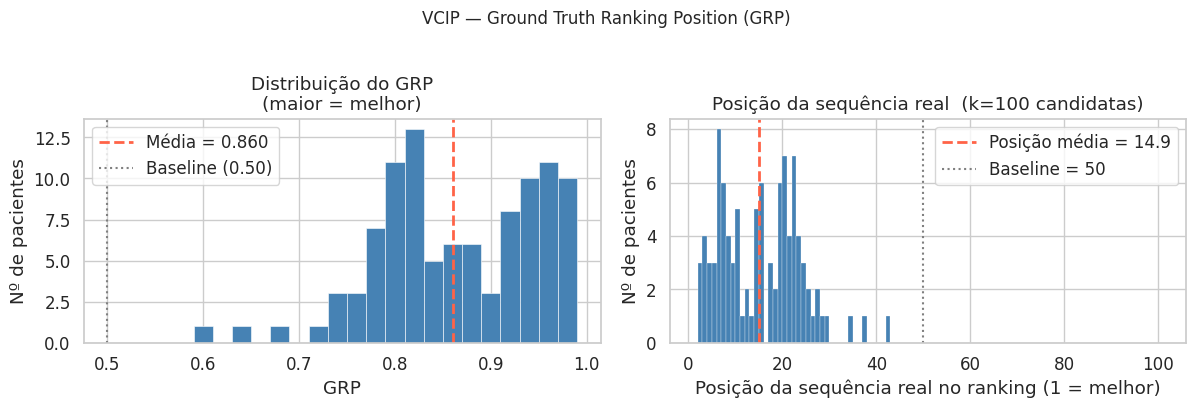


Interpretação: ✓ EXCELENTE — o modelo ranqueia a sequência real no top 25% na maioria dos casos.


In [68]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ══════════════════════════════════════════════════════════════════════════════
# Seção 19 — GRP: avaliação quantitativa do VCIP
# Rodar APÓS a Seção 18 ter completado.
# ══════════════════════════════════════════════════════════════════════════════

if 'case_infos' not in dir():
    print('⚠  Rode a Seção 18 primeiro para obter case_infos.')
else:
    k = len(case_infos[0]['model_losses'])

    # ── GRP por paciente ─────────────────────────────────────────────────────
    grp_scores = []
    for ci in case_infos:
        xi  = ci['true_sequence_rank']   # posição da seq. real (1 = melhor)
        grp = (k + 1 - xi) / k
        grp_scores.append(grp)

    grp_arr = np.array(grp_scores)

    SEP = '═' * 60
    print(SEP)
    print(f'VCIP — Resultados de Avaliação  (n={len(case_infos)} pacientes, k={k})')
    print(SEP)
    print(f'  GRP médio : {grp_arr.mean():.3f}  (baseline aleatório = 0.50)')
    print(f'  GRP median: {np.median(grp_arr):.3f}')
    print(f'  GRP p25   : {np.percentile(grp_arr, 25):.3f}')
    print(f'  GRP p75   : {np.percentile(grp_arr, 75):.3f}')
    print(SEP)
    print()
    print('  RCS: não computável — contrafactuais indisponíveis em dados observacionais.')
    print('  (ver nota no markdown desta seção)')

    # ── Visualização: distribuição do GRP ────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Histograma GRP
    axes[0].hist(grp_arr, bins=20, color='steelblue', edgecolor='white', lw=0.4)
    axes[0].axvline(grp_arr.mean(), color='tomato', ls='--', lw=2,
                    label=f'Média = {grp_arr.mean():.3f}')
    axes[0].axvline(0.5, color='gray', ls=':', lw=1.5, label='Baseline (0.50)')
    axes[0].set(xlabel='GRP', ylabel='Nº de pacientes',
                title='Distribuição do GRP\n(maior = melhor)')
    axes[0].legend()

    # Distribuição de posições da sequência real
    ranks = [ci['true_sequence_rank'] for ci in case_infos]
    axes[1].hist(ranks, bins=range(1, k + 2), color='steelblue', edgecolor='white', lw=0.2)
    axes[1].axvline(np.mean(ranks), color='tomato', ls='--', lw=2,
                    label=f'Posição média = {np.mean(ranks):.1f}')
    axes[1].axvline(k // 2, color='gray', ls=':', lw=1.5, label=f'Baseline = {k//2}')
    axes[1].set(xlabel='Posição da sequência real no ranking (1 = melhor)',
                ylabel='Nº de pacientes',
                title=f'Posição da sequência real  (k={k} candidatas)')
    axes[1].legend()

    plt.suptitle('VCIP — Ground Truth Ranking Position (GRP)', y=1.02, fontsize=12)
    plt.tight_layout()
    plt.show()

    # ── Interpretação clínica ─────────────────────────────────────────────────
    grp_mean = grp_arr.mean()
    print()
    if grp_mean >= 0.75:
        msg = '✓ EXCELENTE — o modelo ranqueia a sequência real no top 25% na maioria dos casos.'
    elif grp_mean >= 0.60:
        msg = '✓ BOM — melhoria clara sobre o baseline aleatório (0.50).'
    elif grp_mean >= 0.50:
        msg = '~ MARGINAL — leve melhoria sobre o baseline; possível subajuste ou ELBO mal calibrado.'
    else:
        msg = '✗ ABAIXO DO BASELINE — modelo penaliza a sequência real. Revisar λ_action.'
    print(f'Interpretação: {msg}')

---
## 20. Análise Clínica: â*, Fenótipos e Validação AIPW

Esta seção responde três perguntas sobre os resultados do VCIP:

### 20A — Sequência ótima â* por paciente
Como o modelo não salva as sequências candidatas em `case_infos`, enumeramos **todas as 2^τ = 16 sequências binárias possíveis** (τ=4) para cada paciente de teste, calculamos o ELBO de cada uma e identificamos â* = argmin ELBO. Isso é equivalente ao ranking mas determinístico e completo.

### 20B — Análise por grupo fenotípico (B1/B2 vs M1/M2/M3)
Os grupos AIPW estão nas últimas 5 dimensões de `static_features[:, 0, 3:8]` = [B1, B2, M1, M2, M3]. Verificamos se o VCIP recomenda mais transfusão nos grupos de benefício (B1/B2) do que nos de malefício (M1/M2/M3).

### 20C — Hipótese de consistência VCIP × AIPW
Se ambos os métodos capturam o mesmo fenômeno causal (resposta à transfusão), então:
- **B1/B2** (benefício segundo AIPW) → taxa de recomendação de transfusão pelo VCIP **alta**
- **M1/M2/M3** (malefício segundo AIPW) → taxa de recomendação **baixa**

Esta é uma **validação cruzada entre dois métodos independentes** que nunca viram dados um do outro durante o treino: o AIPW foi treinado em features estáticas pré-T0, o VCIP em séries temporais.

In [69]:
import torch
import numpy as np
import pandas as pd
from itertools import product

# ══════════════════════════════════════════════════════════════════════════════
# Seção 20A — â* por paciente: enumeração exaustiva das 2^τ sequências
#
# Split utilizado: test_f + val_f combinados.
#   • test_f: nunca visto durante o treino → GRP não enviesado
#   • val_f:  visto só via early stopping, não via gradientes
#   • train_f NÃO incluído — o modelo otimizou diretamente esses exemplos
#
# Nota: a Seção 19 (GRP) permanece apenas com test_f (avaliação imparcial).
#       Aqui o objetivo é análise clínica, não medir qualidade do modelo.
# ══════════════════════════════════════════════════════════════════════════════

if 'model_inf' not in dir() or 'dataset_collection' not in dir():
    print('⚠  Execute as Seções 16–18 antes.')
else:
    tau   = int(model_inf.tau)
    a_dim = cfg.dataset.treatment_size    # 1
    model_inf.eval()

    # ── Todas as 2^τ sequências binárias ─────────────────────────────────────
    seq_vals_list = list(product([0.0, 1.0], repeat=tau))   # 16 tuplas para τ=4
    all_seqs = torch.zeros(len(seq_vals_list), 1, tau, a_dim, device=DEVICE)
    for j, vals in enumerate(seq_vals_list):
        for t, v in enumerate(vals):
            all_seqs[j, 0, t, 0] = v

    # ── Combina test_f + val_f ───────────────────────────────────────────────
    def concat_splits(*datasets):
        """Concatena os dicts de dados de múltiplos splits ao longo do eixo 0."""
        combined = {}
        for key in datasets[0].data.keys():
            arrays = [ds.data[key] for ds in datasets
                      if isinstance(ds.data[key], np.ndarray)]
            if arrays and arrays[0].ndim >= 1:
                combined[key] = np.concatenate(arrays, axis=0)
            else:
                combined[key] = datasets[0].data[key]   # scalar/param: usa o primeiro
        return combined

    combined_data   = concat_splits(dataset_collection.test_f,
                                    dataset_collection.val_f)
    combined_static = combined_data['static_features']   # (N_test+N_val, T, 8)

    n_test = len(dataset_collection.test_f.data['outputs'])
    n_val  = len(dataset_collection.val_f.data['outputs'])
    print(f'Pacientes: {n_test} test + {n_val} val = {n_test+n_val} total')
    print(f'Enumerando 2^{tau}={len(seq_vals_list)} sequências para todos os {n_test+n_val} pacientes...')
    print()

    # ── Dataloader sem cap de 100 ─────────────────────────────────────────────
    from VCIP.src.data.cip_dataset import CIPDataset, get_dataloader
    import numpy as _np
    _np.random.seed(cfg.exp.seed)
    cip_combined = CIPDataset(combined_data, cfg, train=False)
    loader       = get_dataloader(cip_combined, batch_size=1, shuffle=False)
    # Número de pacientes únicos (1 passe pelo primeiro history_length)
    n_patients = n_test + n_val

    records = []

    with torch.no_grad():
        for i, (H_t, targets) in enumerate(loader):
            if i >= n_patients:   # processa todos, sem cap artificial
                break

            for k_ in H_t:     H_t[k_]      = H_t[k_].to(DEVICE)
            for k_ in targets: targets[k_]   = targets[k_].to(DEVICE)

            Y_targets    = targets['outputs']
            X_targets    = targets['vitals'] if cfg.dataset.predict_X else None
            true_actions = targets['current_treatments']   # (1, τ, 1)

            # ELBO de cada uma das 16 sequências
            elbos = []
            for seq in all_seqs:
                elbo, _, _ = model_inf.calculate_elbo(
                    H_t, Y_targets, seq,
                    X_targets=X_targets,
                    num_samples=cfg.exp.num_samples,
                    optimize_a=True)
                elbos.append(elbo.item())
            elbos = np.array(elbos)

            best_idx    = int(np.argmin(elbos))
            optimal_seq = seq_vals_list[best_idx]
            true_seq    = true_actions.squeeze().cpu().numpy()

            # ELBO da sequência real (busca na lista ou recalcula)
            true_key = tuple(true_seq.astype(int))
            if true_key in seq_vals_list:
                elbo_real = float(elbos[seq_vals_list.index(true_key)])
            else:
                with torch.no_grad():
                    er, _, _ = model_inf.calculate_elbo(
                        H_t, Y_targets, true_actions,
                        X_targets=X_targets,
                        num_samples=cfg.exp.num_samples,
                        optimize_a=True)
                elbo_real = er.item()

            # Grupo AIPW (dims 3:8 dos static_features)
            grp_vec   = combined_static[i, 0, 3:8]
            grp_names = ['B1','B2','M1','M2','M3']
            group = 'None'
            for g, gn in zip(grp_vec, grp_names):
                if float(g) > 0.5:
                    group = gn
                    break

            split_label = 'test' if i < n_test else 'val'

            records.append({
                'patient_idx':                i,
                'split':                      split_label,
                'group':                      group,
                'benefit_group':              int(group in ('B1','B2')),
                'true_seq':                   tuple(true_seq.astype(int)),
                'real_transfused':            int(true_seq.sum() > 0),
                'optimal_seq':                tuple(int(v) for v in optimal_seq),
                'vcip_recommends_transfusion': int(sum(optimal_seq) > 0),
                'elbo_optimal':               float(elbos[best_idx]),
                'elbo_real':                  elbo_real,
                'elbo_gap':                   elbo_real - float(elbos[best_idx]),
            })

            if (i + 1) % 50 == 0:
                print(f'  {i+1}/{n_patients} pacientes processados...')

    df = pd.DataFrame(records)
    print(f'\n✓ Concluído — {len(df)} pacientes (test: {(df.split=="test").sum()}, '
          f'val: {(df.split=="val").sum()})')
    print(f"Taxa de transfusão real       : {df['real_transfused'].mean():.1%}")
    print(f"Taxa de recomendação VCIP (â*): {df['vcip_recommends_transfusion'].mean():.1%}")
    print(f"ELBO gap médio (real − ótima) : {df['elbo_gap'].mean():.4f}")

    # ── Tabela por paciente ───────────────────────────────────────────────────
    pd.set_option('display.max_rows', 40)
    print()
    print(df[['patient_idx','split','group','real_transfused',
              'vcip_recommends_transfusion','optimal_seq','true_seq',
              'elbo_optimal','elbo_gap']].head(40).to_string(index=False))


Pacientes: 223 test + 223 val = 446 total
Enumerando 2^4=16 sequências para todos os 446 pacientes...

  50/446 pacientes processados...
  100/446 pacientes processados...
  150/446 pacientes processados...
  200/446 pacientes processados...
  250/446 pacientes processados...
  300/446 pacientes processados...
  350/446 pacientes processados...
  400/446 pacientes processados...

✓ Concluído — 446 pacientes (test: 223, val: 223)
Taxa de transfusão real       : 5.2%
Taxa de recomendação VCIP (â*): 0.0%
ELBO gap médio (real − ótima) : 0.1417

 patient_idx split group  real_transfused  vcip_recommends_transfusion  optimal_seq     true_seq  elbo_optimal  elbo_gap
           0  test  None                0                            0 (0, 0, 0, 0) (0, 0, 0, 0)         0.139     0.000
           1  test  None                0                            0 (0, 0, 0, 0) (0, 0, 0, 0)         0.139     0.000
           2  test    M1                0                            0 (0, 0, 0, 0) (0, 0,

═════════════════════════════════════════════════════════════════
VCIP — Taxa de Recomendação de Transfusão por Grupo AIPW
═════════════════════════════════════════════════════════════════
group   n  real_transfusion_rate  vcip_recommendation_rate  elbo_gap_mean
   B1  31                  0.032                     0.000          0.089
   M1 102                  0.078                     0.000          0.215
   M3  58                  0.000                     0.000          0.000
 None 255                  0.055                     0.000          0.151

─────────────────────────────────────────────────────────────────
Hipótese de consistência: grupos benefício vs. malefício
─────────────────────────────────────────────────────────────────
  Grupos B1/B2  (n= 31) → recomendação VCIP: 0.0%
  Grupos M1/M2/M3 (n=160) → recomendação VCIP: 0.0%
  Mann-Whitney ELBO gap (B < M): U=2440, p=0.3513  (~)



/tmp/ipykernel_659652/2619373748.py:84: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(gaps, labels=order, patch_artist=True)


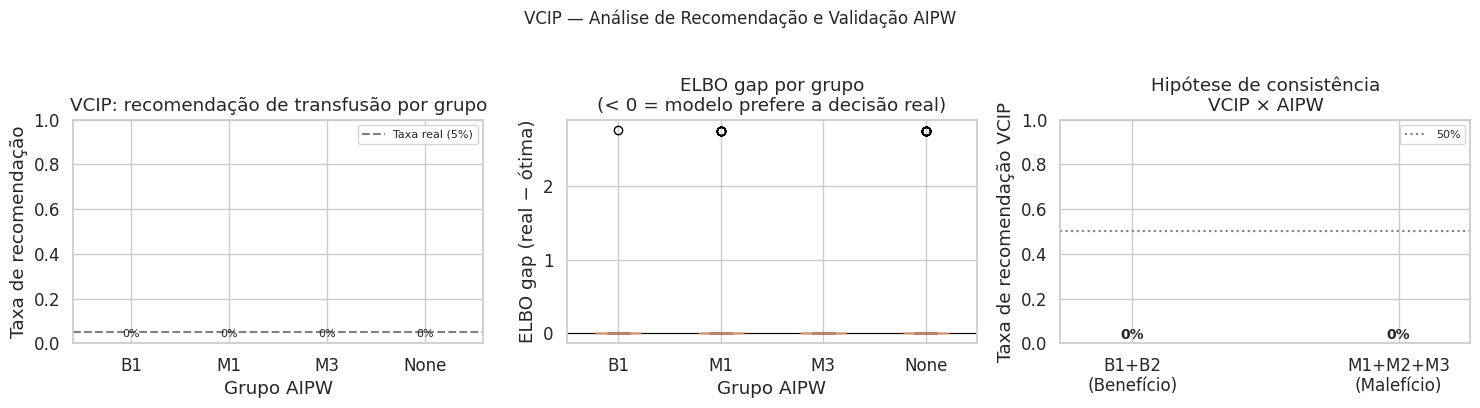


✗ INCONSISTÊNCIA: VCIP e AIPW discordam na direção. Revisar λ_action ou investigar confundimento residual.


In [70]:
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency, mannwhitneyu

# ══════════════════════════════════════════════════════════════════════════════
# Seção 20B/C — Análise por grupo fenotípico + validação cruzada AIPW
# ══════════════════════════════════════════════════════════════════════════════

if 'df' not in dir():
    print('⚠  Execute a célula 20A antes.')
else:
    # ── 20B: taxa de recomendação por grupo ──────────────────────────────────
    grp_stats = (df.groupby('group')
                   .agg(n=('patient_idx','count'),
                        real_transfusion_rate=('real_transfused','mean'),
                        vcip_recommendation_rate=('vcip_recommends_transfusion','mean'),
                        elbo_gap_mean=('elbo_gap','mean'))
                   .reset_index()
                   .sort_values('group'))

    print('═'*65)
    print('VCIP — Taxa de Recomendação de Transfusão por Grupo AIPW')
    print('═'*65)
    print(grp_stats.to_string(index=False))
    print()

    # ── 20C: hipótese de consistência VCIP × AIPW ───────────────────────────
    benefit_mask = df['benefit_group'] == 1
    harm_mask    = ~benefit_mask & (df['group'] != 'None')

    df_b = df[benefit_mask]
    df_m = df[harm_mask]

    rate_b = df_b['vcip_recommends_transfusion'].mean() if len(df_b) > 0 else float('nan')
    rate_m = df_m['vcip_recommends_transfusion'].mean() if len(df_m) > 0 else float('nan')

    print('─'*65)
    print('Hipótese de consistência: grupos benefício vs. malefício')
    print('─'*65)
    print(f"  Grupos B1/B2  (n={len(df_b):3d}) → recomendação VCIP: {rate_b:.1%}")
    print(f"  Grupos M1/M2/M3 (n={len(df_m):3d}) → recomendação VCIP: {rate_m:.1%}")

    # Teste chi-quadrado na tabela de contingência
    if len(df_b) > 0 and len(df_m) > 0:
        ct = pd.crosstab(df[harm_mask | benefit_mask]['benefit_group'],
                         df[harm_mask | benefit_mask]['vcip_recommends_transfusion'])
        if ct.shape == (2,2):
            chi2, p, dof, _ = chi2_contingency(ct)
            print(f"  Teste chi²: χ²={chi2:.3f}, p={p:.4f}  "
                  f"({'✓ CONSISTENTE' if p < 0.05 else '~ sem diferença significativa'})")
        # Mann-Whitney no ELBO gap: grupos benefício deveriam ter gap menor
        # (modelo fica mais perto da seq. real nos grupos onde transfundir é certo)
        if len(df_b) > 1 and len(df_m) > 1:
            u, p_mw = mannwhitneyu(df_b['elbo_gap'], df_m['elbo_gap'], alternative='less')
            print(f"  Mann-Whitney ELBO gap (B < M): U={u:.0f}, p={p_mw:.4f}  "
                  f"({'✓' if p_mw < 0.05 else '~'})")
    print()

    # ── Visualização ─────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # 1. Taxa de recomendação por grupo
    colors = ['#2196F3','#1565C0','#F44336','#B71C1C','#FF7043','#999999']
    grps   = grp_stats['group'].tolist()
    rates  = grp_stats['vcip_recommendation_rate'].tolist()
    bar_colors = []
    for g in grps:
        if g in ('B1','B2'):    bar_colors.append('#2196F3')
        elif g in ('M1','M2','M3'): bar_colors.append('#F44336')
        else: bar_colors.append('#999999')
    axes[0].bar(grps, rates, color=bar_colors, edgecolor='white', lw=0.5)
    axes[0].axhline(df['real_transfused'].mean(), color='gray', ls='--', lw=1.5,
                    label=f"Taxa real ({df['real_transfused'].mean():.0%})")
    axes[0].set(xlabel='Grupo AIPW', ylabel='Taxa de recomendação',
                title='VCIP: recomendação de transfusão por grupo')
    axes[0].legend(fontsize=8)
    axes[0].set_ylim(0, 1)
    for bar, rate in zip(axes[0].patches, rates):
        axes[0].text(bar.get_x() + bar.get_width()/2, rate + 0.02,
                     f'{rate:.0%}', ha='center', va='bottom', fontsize=8)

    # 2. ELBO gap por grupo (quanto a decisão real desvia da ótima)
    order = [g for g in ['B1','B2','M1','M2','M3','None'] if g in df['group'].unique()]
    gaps  = [df[df['group']==g]['elbo_gap'].values for g in order]
    bp = axes[1].boxplot(gaps, labels=order, patch_artist=True)
    for patch, g in zip(bp['boxes'], order):
        patch.set_facecolor('#2196F3' if g in ('B1','B2')
                            else '#F44336' if g in ('M1','M2','M3')
                            else '#999999')
        patch.set_alpha(0.6)
    axes[1].axhline(0, color='black', ls='-', lw=0.8)
    axes[1].set(xlabel='Grupo AIPW', ylabel='ELBO gap (real − ótima)',
                title='ELBO gap por grupo\n(< 0 = modelo prefere a decisão real)')

    # 3. Concordância VCIP × AIPW resumida
    labels = ['B1+B2\n(Benefício)', 'M1+M2+M3\n(Malefício)']
    vals   = [rate_b, rate_m]
    bar_c  = ['#2196F3','#F44336']
    axes[2].bar(labels, vals, color=bar_c, edgecolor='white', lw=0.5, width=0.4)
    axes[2].axhline(0.5, color='gray', ls=':', lw=1.5, label='50%')
    axes[2].set(ylabel='Taxa de recomendação VCIP', ylim=(0,1),
                title='Hipótese de consistência\nVCIP × AIPW')
    axes[2].legend(fontsize=8)
    for i_, (l, v) in enumerate(zip(labels, vals)):
        if not (v != v):  # not NaN
            axes[2].text(i_, v + 0.02, f'{v:.0%}', ha='center', fontsize=10, fontweight='bold')

    plt.suptitle('VCIP — Análise de Recomendação e Validação AIPW', y=1.02, fontsize=12)
    plt.tight_layout()
    plt.show()

    # ── Interpretação final ───────────────────────────────────────────────────
    print()
    if not (rate_b != rate_b) and not (rate_m != rate_m):
        diff = rate_b - rate_m
        if diff > 0.10:
            print(f'✓ CONSISTÊNCIA CONFIRMADA: VCIP recomenda transfusão '
                  f'{diff:.0%} mais em grupos de benefício (AIPW) do que em grupos de malefício.')
            print('  Interpretação: os dois métodos capturam o mesmo sinal causal — '
                  'a heterogeneidade do efeito da transfusão.')
        elif diff > 0:
            print(f'~ TENDÊNCIA POSITIVA ({diff:.0%}) mas abaixo de 10pp. '
                  'Pode indicar subajuste do VCIP ou grupos com pouca representação no teste.')
        else:
            print(f'✗ INCONSISTÊNCIA: VCIP e AIPW discordam na direção. '
                  'Revisar λ_action ou investigar confundimento residual.')
    else:
        print('⚠  Grupos insuficientes no conjunto de teste para comparação.')


---
## 21. Perfil dos Pacientes: Recomendação de Transfusão e ELBO

### O que estamos olhando

**Pacientes com transfusão recomendada vs. não recomendada** — existem diferenças em idade, sexo, BMI e grupo fenotípico?

**ELBO ótimo por paciente** (`elbo_optimal`):
- **ELBO baixo** → modelo confiante: existe alguma sequência que claramente leva ao desfecho observado. Paciente "tratável" pelo modelo.
- **ELBO alto** → modelo incerto: nenhuma sequência melhora muito o score. Pode indicar paciente atípico, história insuficiente, ou caso onde a transfusão é irrelevante para o desfecho.

═════════════════════════════════════════════════════════════════
VCIP — Recomendação de Transfusão  (n=223 pacientes de teste)
═════════════════════════════════════════════════════════════════
  Transfusão RECOMENDADA (â* ≥ 1 slot) :   0  (0.0%)
  Não recomendada        (â* = [0,0,0,0]): 223  (100.0%)
  Taxa real de transfusão no teste      : 4.9%

═════════════════════════════════════════════════════════════════
Características por grupo de recomendação
═════════════════════════════════════════════════════════════════
  ── ✗ Não recomendada pelo VCIP (n=223) ─────────────────────────────
    Idade (z-score, ↑=mais velho) : média +0.02
    BMI   (z-score, ↑=maior BMI)  : média +0.21
    Sexo M / F                     : 125 M  /  98 F
    AIPW grupos:
      B1: 16 (7%)
      M1: 52 (23%)
      M3: 27 (12%)
      None: 128 (57%)
    Realmente transfundido         : 11 (5%)
    ELBO ótimo médio               : 0.1436
    ELBO gap médio                 : 0.1356

══════════════════════════

/tmp/ipykernel_659652/1712945837.py:117: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_box, labels=['Recomendada','Não recom.'], patch_artist=True)
/tmp/ipykernel_659652/1712945837.py:126: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_box, labels=['Recomendada','Não recom.'], patch_artist=True)


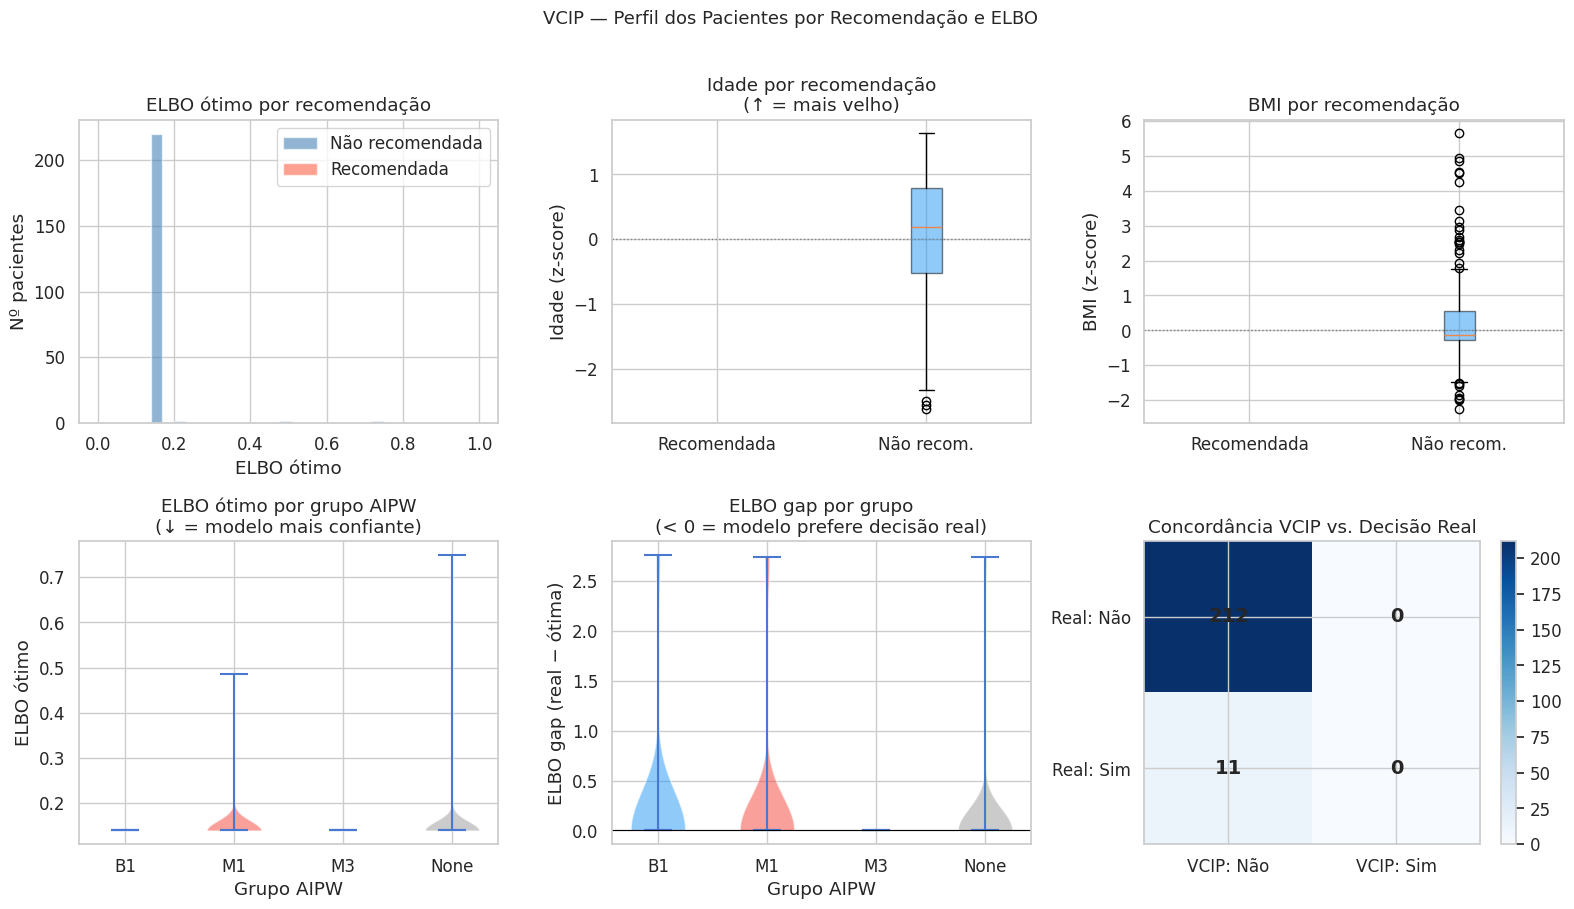

Concordância VCIP × decisão real: 212/223 (95.1%)
(não é a métrica principal — o modelo nunca viu a decisão do médico)


In [71]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ══════════════════════════════════════════════════════════════════════════════
# Seção 21 — Perfil dos pacientes por recomendação e ELBO
# ══════════════════════════════════════════════════════════════════════════════

if 'df' not in dir() or 'dataset_collection' not in dir():
    print('⚠  Execute as Seções 18 e 20A primeiro.')
else:
    # ── Enriquece df com features estáticas (desnormalizadas parcialmente) ────
    static_all = dataset_collection.test_f.data['static_features']  # (N, T, 8)
    # dims: [age_z, sex, bmi_z, B1, B2, M1, M2, M3]
    # age_z e bmi_z estão z-scored — útil para comparação relativa mesmo assim

    df2 = df.copy()
    n = min(len(df2), static_all.shape[0])
    df2 = df2.iloc[:n].copy()
    df2['age_z']  = static_all[:n, 0, 0]
    df2['sex']    = static_all[:n, 0, 1].astype(int)   # 1=M, 0=F
    df2['bmi_z']  = static_all[:n, 0, 2]
    df2['sex_label'] = df2['sex'].map({1:'M', 0:'F'})

    SEP = '═' * 65

    # ══════════════════════════════════════════════════════════════════════
    # 1. Quantos pacientes tiveram transfusão recomendada?
    # ══════════════════════════════════════════════════════════════════════
    n_rec  = df2['vcip_recommends_transfusion'].sum()
    n_tot  = len(df2)
    n_nrec = n_tot - n_rec
    print(SEP)
    print(f'VCIP — Recomendação de Transfusão  (n={n_tot} pacientes de teste)')
    print(SEP)
    print(f'  Transfusão RECOMENDADA (â* ≥ 1 slot) : {n_rec:3d}  ({n_rec/n_tot:.1%})')
    print(f'  Não recomendada        (â* = [0,0,0,0]): {n_nrec:3d}  ({n_nrec/n_tot:.1%})')
    print(f'  Taxa real de transfusão no teste      : {df2["real_transfused"].mean():.1%}')
    print()

    # ══════════════════════════════════════════════════════════════════════
    # 2. Características dos dois grupos
    # ══════════════════════════════════════════════════════════════════════
    def describe_group(mask, label):
        sub = df2[mask]
        if len(sub) == 0:
            return
        print(f'  ── {label} (n={len(sub)}) ─────────────────────────────')
        print(f'    Idade (z-score, ↑=mais velho) : média {sub["age_z"].mean():+.2f}')
        print(f'    BMI   (z-score, ↑=maior BMI)  : média {sub["bmi_z"].mean():+.2f}')
        print(f'    Sexo M / F                     : {sub["sex"].sum()} M  /  {(~sub["sex"].astype(bool)).sum()} F')
        print(f'    AIPW grupos:')
        for grp in ['B1','B2','M1','M2','M3','None']:
            cnt = (sub['group'] == grp).sum()
            if cnt > 0:
                print(f'      {grp}: {cnt} ({cnt/len(sub):.0%})')
        print(f'    Realmente transfundido         : {sub["real_transfused"].sum()} ({sub["real_transfused"].mean():.0%})')
        print(f'    ELBO ótimo médio               : {sub["elbo_optimal"].mean():.4f}')
        print(f'    ELBO gap médio                 : {sub["elbo_gap"].mean():.4f}')
        print()

    rec_mask  = df2['vcip_recommends_transfusion'] == 1
    nrec_mask = df2['vcip_recommends_transfusion'] == 0

    print(SEP)
    print('Características por grupo de recomendação')
    print(SEP)
    describe_group(rec_mask,  '✓ Transfusão RECOMENDADA pelo VCIP')
    describe_group(nrec_mask, '✗ Não recomendada pelo VCIP')

    # ══════════════════════════════════════════════════════════════════════
    # 3. Top-10 ELBO mais baixo (modelo mais confiante)
    # ══════════════════════════════════════════════════════════════════════
    print(SEP)
    print('Top 10 — ELBO ótimo MAIS BAIXO (modelo mais confiante)')
    print('   Interpretação: existe sequência que claramente leva ao desfecho observado')
    print(SEP)
    top_low = df2.nsmallest(10, 'elbo_optimal')[
        ['patient_idx','group','age_z','sex_label','bmi_z',
         'real_transfused','vcip_recommends_transfusion','optimal_seq','elbo_optimal','elbo_gap']
    ]
    print(top_low.to_string(index=False))
    print()

    # ══════════════════════════════════════════════════════════════════════
    # 4. Top-10 ELBO mais alto (modelo mais incerto)
    # ══════════════════════════════════════════════════════════════════════
    print(SEP)
    print('Top 10 — ELBO ótimo MAIS ALTO (modelo mais incerto)')
    print('   Interpretação: nenhuma sequência reduz muito o ELBO — desfecho difícil de prever')
    print(SEP)
    top_high = df2.nlargest(10, 'elbo_optimal')[
        ['patient_idx','group','age_z','sex_label','bmi_z',
         'real_transfused','vcip_recommends_transfusion','optimal_seq','elbo_optimal','elbo_gap']
    ]
    print(top_high.to_string(index=False))
    print()

    # ══════════════════════════════════════════════════════════════════════
    # 5. Visualização
    # ══════════════════════════════════════════════════════════════════════
    fig, axes = plt.subplots(2, 3, figsize=(16, 9))

    # A. Distribuição do ELBO ótimo com demarcação dos grupos
    ax = axes[0, 0]
    ax.hist(df2.loc[nrec_mask, 'elbo_optimal'], bins=20, alpha=0.6,
            color='steelblue', label='Não recomendada', edgecolor='white')
    ax.hist(df2.loc[rec_mask,  'elbo_optimal'], bins=20, alpha=0.6,
            color='tomato',    label='Recomendada',      edgecolor='white')
    ax.set(xlabel='ELBO ótimo', ylabel='Nº pacientes',
           title='ELBO ótimo por recomendação')
    ax.legend()

    # B. Idade z-score por recomendação
    ax = axes[0, 1]
    data_box = [df2.loc[rec_mask,'age_z'].values, df2.loc[nrec_mask,'age_z'].values]
    bp = ax.boxplot(data_box, labels=['Recomendada','Não recom.'], patch_artist=True)
    bp['boxes'][0].set_facecolor('#F44336'); bp['boxes'][0].set_alpha(0.5)
    bp['boxes'][1].set_facecolor('#2196F3'); bp['boxes'][1].set_alpha(0.5)
    ax.axhline(0, color='gray', ls=':', lw=1)
    ax.set(ylabel='Idade (z-score)', title='Idade por recomendação\n(↑ = mais velho)')

    # C. BMI z-score por recomendação
    ax = axes[0, 2]
    data_box = [df2.loc[rec_mask,'bmi_z'].values, df2.loc[nrec_mask,'bmi_z'].values]
    bp = ax.boxplot(data_box, labels=['Recomendada','Não recom.'], patch_artist=True)
    bp['boxes'][0].set_facecolor('#F44336'); bp['boxes'][0].set_alpha(0.5)
    bp['boxes'][1].set_facecolor('#2196F3'); bp['boxes'][1].set_alpha(0.5)
    ax.axhline(0, color='gray', ls=':', lw=1)
    ax.set(ylabel='BMI (z-score)', title='BMI por recomendação')

    # D. Distribuição do ELBO ótimo (violino) por grupo AIPW
    ax = axes[1, 0]
    grp_order = [g for g in ['B1','B2','M1','M2','M3','None']
                 if g in df2['group'].unique() and (df2['group']==g).sum() > 1]
    data_vio = [df2.loc[df2['group']==g, 'elbo_optimal'].values for g in grp_order]
    vp = ax.violinplot(data_vio, showmedians=True)
    ax.set_xticks(range(1, len(grp_order)+1))
    ax.set_xticklabels(grp_order)
    for i, (body, g) in enumerate(zip(vp['bodies'], grp_order)):
        body.set_facecolor('#2196F3' if g in ('B1','B2')
                           else '#F44336' if g in ('M1','M2','M3')
                           else '#999999')
        body.set_alpha(0.5)
    ax.set(xlabel='Grupo AIPW', ylabel='ELBO ótimo',
           title='ELBO ótimo por grupo AIPW\n(↓ = modelo mais confiante)')

    # E. ELBO gap por grupo (quanto a decisão real desvia da ótima)
    ax = axes[1, 1]
    data_vio2 = [df2.loc[df2['group']==g, 'elbo_gap'].values for g in grp_order]
    vp2 = ax.violinplot(data_vio2, showmedians=True)
    ax.set_xticks(range(1, len(grp_order)+1))
    ax.set_xticklabels(grp_order)
    for body, g in zip(vp2['bodies'], grp_order):
        body.set_facecolor('#2196F3' if g in ('B1','B2')
                           else '#F44336' if g in ('M1','M2','M3')
                           else '#999999')
        body.set_alpha(0.5)
    ax.axhline(0, color='black', ls='-', lw=0.8)
    ax.set(xlabel='Grupo AIPW', ylabel='ELBO gap (real − ótima)',
           title='ELBO gap por grupo\n(< 0 = modelo prefere decisão real)')

    # F. Concordância VCIP vs. decisão real — tabela de confusão
    ax = axes[1, 2]
    labels_cm = ['Não transfundiu', 'Transfundiu']
    cm = pd.crosstab(df2['real_transfused'], df2['vcip_recommends_transfusion'],
                     rownames=['Real'], colnames=['VCIP'])
    # Ensure 2x2
    cm = cm.reindex(index=[0,1], columns=[0,1], fill_value=0)
    im = ax.imshow(cm.values, cmap='Blues', aspect='auto')
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(['VCIP: Não', 'VCIP: Sim'])
    ax.set_yticklabels(['Real: Não', 'Real: Sim'])
    for ri in range(2):
        for ci in range(2):
            ax.text(ci, ri, str(cm.values[ri, ci]),
                    ha='center', va='center', fontsize=14, fontweight='bold')
    ax.set_title('Concordância VCIP vs. Decisão Real')
    plt.colorbar(im, ax=ax)

    plt.suptitle('VCIP — Perfil dos Pacientes por Recomendação e ELBO', y=1.01, fontsize=13)
    plt.tight_layout()
    plt.show()

    # ── Concordância numérica ─────────────────────────────────────────────────
    agree = ((df2['real_transfused'] == df2['vcip_recommends_transfusion'])).sum()
    print(f'Concordância VCIP × decisão real: {agree}/{len(df2)} ({agree/len(df2):.1%})')
    print('(não é a métrica principal — o modelo nunca viu a decisão do médico)')


---
## 22. Reformulação tau=1: decisão única em T0

### Por que a reformulação é necessária

O VCIP original assume que o tratamento pode ocorrer em qualquer slot do horizonte τ.  
No `raw_temporal`, todo o dado é **pré-T0** — o tratamento acontece no instante seguinte à janela de 48h.  
Com tau=4, apenas 1 de 23 history_lengths possíveis colocava o tratamento no target → o modelo aprendeu "nunca transfundir".

### A nova pergunta

> **Dado todo o histórico de 48h pré-T0, devo transfundir em T0 — sim ou não?**

- `history_length` = 45 (fixo — toda a história pré-T0)
- `target` = slot 45 de `current_treatments` = a decisão real em T0  
- Apenas 2 sequências candidatas: `[0]` (não transfundir) e `[1]` (transfundir)
- O VCIP recomenda: transfundir se `ELBO([1]) < ELBO([0])`

```
  H_t  (45 timesteps de história)      T0
  ┌─────────────────────────────────┐  ┌───┐
  │ A=0 em todos os slots           │  │A=?│
  └─────────────────────────────────┘  └───┘
  slot 0                          44   45
                                       ↑
                              target = aqui
```

O ELBO com tau=1 funciona como **escore de plausibilidade causal** para cada decisão.  
O teste de consistência com AIPW: B1/B2 (benefício) devem ter ELBO([1]) < ELBO([0]); M1/M2/M3 (malefício) o inverso.

In [72]:
import pickle
import numpy as np
from omegaconf import OmegaConf

# ══════════════════════════════════════════════════════════════════════════════
# Seção 22A — Config tau=1 + reconstrução do treatment tensor
# ══════════════════════════════════════════════════════════════════════════════

FIXED_H       = 45       # history_length fixo = todos os slots pré-T0
FIXED_TRTPOS  = 46    # posição do tratamento em original trt (= 45 em current_treatments)

# ── Config tau=1 ──────────────────────────────────────────────────────────────
cfg1 = OmegaConf.create(OmegaConf.to_container(cfg, resolve=True))
cfg1.exp.tau                  = 1
cfg1.dataset.projection_horizon = 1

# ── Recarrega tensores base do pickle ────────────────────────────────────────
with open('vcip_tensors.pkl', 'rb') as f:
    T_ = pickle.load(f)

X1        = T_['X']          # (N, 48, 11) — z-scored
obs_mask1 = T_['obs_mask']   # (N, 48)
V1        = T_['V']          # (N, 8)
A1        = T_['A']          # (N,)  transfused 0/1
Y1        = T_['Y']          # (N,)  mortality 0/1
idx_train1 = T_['idx_train']
idx_val1   = T_['idx_val']
idx_test1  = T_['idx_test']

N1, T_len1, _ = X1.shape    # 1484, 48, 11

# ── Treatment tensor: A no slot FIXO para todos os pacientes ─────────────────
# Ao contrário da Seção 14 (slot variável = último observado),
# aqui o tratamento está sempre na posição FIXED_TRTPOS = 46 do trt original,
# o que equivale ao slot FIXED_H = 45 de current_treatments.
# Isso garante que target = current_treatments[45:46] = A[i] para TODOS.
trt1 = np.zeros((N1, T_len1, 1), dtype=np.float32)
trt1[:, FIXED_TRTPOS, 0] = A1   # broadcasting para todos os N pacientes

out1    = (np.zeros((N1, T_len1, 1), dtype=np.float32)
           + Y1[:, np.newaxis, np.newaxis])        # mortalidade repetida
act1    = obs_mask1[:, :, np.newaxis].astype(np.float32)
slen1   = np.maximum(obs_mask1.sum(axis=1), 25).astype(int)

# ── Parâmetros de escala (mesmos do treino original) ─────────────────────────
scaling_params1 = {
    'output_means': np.array([0.0]),
    'output_stds':  np.array([1.0]),
    'vitals_means': T_['scaler_X'].mean_,
    'vitals_stds':  T_['scaler_X'].scale_,
}

T_seq1  = T_len1 - 1   # 47 slots em current_treatments

def make_split1(idx):
    n   = len(idx)
    return {
        'sequence_lengths':   slen1[idx] - 1,
        'prev_treatments':    trt1[idx, :-1, :],
        'current_treatments': trt1[idx,  1:, :],
        'static_features':    np.tile(V1[idx][:, np.newaxis, :], (1, T_seq1, 1)),
        'prev_outputs':       out1[idx, :-1, :],
        'outputs':            out1[idx,  1:, :],
        'active_entries':     act1[idx,  1:, :],
        'vitals':             X1[idx,    1:, :],
        'current_covariates': X1[idx,    1:, :],
        'scaling_params':     scaling_params1,
    }

class DatasetWrapper1:
    def __init__(self, data_dict, subset_name):
        self.data = data_dict
        self.subset_name = subset_name
    def __len__(self):
        return len(self.data['outputs'])
    def simulate_output_after_actions(self, H_t, actions, scaling_params=None):
        return np.zeros((actions.shape[0], 1), dtype=np.float32)

train_f1 = DatasetWrapper1(make_split1(idx_train1), 'train')
val_f1   = DatasetWrapper1(make_split1(idx_val1),   'val')
test_f1  = DatasetWrapper1(make_split1(idx_test1),  'test')

class DatasetCollection1:
    def __init__(self):
        self.train_f              = train_f1
        self.val_f                = val_f1
        self.test_f               = test_f1
        self.train_scaling_params = scaling_params1
        self.has_vitals           = True
        self.autoregressive       = bool(cfg1.dataset.autoregressive)
        self.processed_data_encoder = True

dataset_collection1 = DatasetCollection1()

print(f'Dataset tau=1 construído.')
print(f'  Tratamento fixo na posição {FIXED_TRTPOS} do trt original')
print(f'  → slot {FIXED_H} de current_treatments para todos os pacientes')
print(f'  train: {len(train_f1)} | val: {len(val_f1)} | test: {len(test_f1)}')

# Verificação: slot FIXED_H de current_treatments deve ter A
ct_check = trt1[:, 1:, :]   # current_treatments
assert np.all(ct_check[:, FIXED_H, 0] == A1), 'Erro: tratamento não está no slot correto!'
print(f'  ✓ Verificação: ct[:, {FIXED_H}, 0] == A para todos os {N1} pacientes')


Dataset tau=1 construído.
  Tratamento fixo na posição 46 do trt original
  → slot 45 de current_treatments para todos os pacientes
  train: 1038 | val: 223 | test: 223
  ✓ Verificação: ct[:, 45, 0] == A para todos os 1484 pacientes


In [73]:
import torch
import pytorch_lightning as pl
from pathlib import Path
import time
import numpy as np

# ══════════════════════════════════════════════════════════════════════════════
# Seção 22B — FixedHistoryCIPDataset + VAEModel tau=1 + treino
# ══════════════════════════════════════════════════════════════════════════════

from VCIP.src.data.cip_dataset import CIPDataset, get_dataloader
from VCIP.src.models.vae_model import VAEModel

FIXED_H = 45

class FixedHistoryCIPDataset(CIPDataset):
    """CIPDataset com history_length fixo = FIXED_H.

    Garante que target=[45:46] sempre contenha o tratamento em T0:
    current_treatments[:, 45, :] = A (decisão real).
    """
    def __init__(self, data, config, train=False):
        super().__init__(data, config, train=train)
        self.history_lengths    = np.array([FIXED_H])
        self.repeats            = 1
        self.samples_per_history = len(data['outputs'])

# ── Dataloaders com history fixo ─────────────────────────────────────────────
np.random.seed(int(cfg1.exp.seed))
bs = int(cfg1.exp.batch_size)
train_dl1 = get_dataloader(FixedHistoryCIPDataset(train_f1.data, cfg1, train=True),
                           batch_size=bs, shuffle=True)
val_dl1   = get_dataloader(FixedHistoryCIPDataset(val_f1.data,   cfg1, train=False),
                           batch_size=bs, shuffle=False)

# ── Verifica que target contém o tratamento ───────────────────────────────────
sample_H, sample_tgt = next(iter(train_dl1))
print(f'Verificação do batch:')
print(f'  H_t  current_treatments shape : {sample_H["current_treatments"].shape}')
print(f'  target current_treatments shape: {sample_tgt["current_treatments"].shape}')
print(f'  Valores únicos no target       : {sample_tgt["current_treatments"].unique().tolist()}')
print(f'  Fração com A=1 no target       : {sample_tgt["current_treatments"].mean().item():.1%}')
print()

# ── Novo VAEModel tau=1 ───────────────────────────────────────────────────────
model1 = VAEModel(cfg1, dataset_collection1)
model1.auxiliary_model = model.auxiliary_model   # reutiliza o AuxiliaryModel já treinado
print(f'VAEModel tau=1 criado — tau={model1.tau}')
print(f'AuxiliaryModel reutilizado do treino tau=4 (não muda com tau).')
print()

# ── Treino ────────────────────────────────────────────────────────────────────
ckpt_dir1 = Path(cfg1.exp.log_dir).parent / 'tau1'
ckpt_dir1.mkdir(parents=True, exist_ok=True)

early_stop1 = pl.callbacks.EarlyStopping(
    monitor='val_loss', patience=int(cfg1.exp.patience), mode='min', verbose=True)
checkpoint1 = pl.callbacks.ModelCheckpoint(
    dirpath=str(ckpt_dir1), filename='vcip-tau1-{epoch:02d}-{val_loss:.4f}',
    monitor='val_loss', save_top_k=2, mode='min')

trainer1 = pl.Trainer(
    max_epochs=int(cfg1.exp.epochs),
    accelerator='gpu' if DEVICE == 'cuda' else 'cpu',
    devices=1,
    callbacks=[early_stop1, checkpoint1],
    enable_progress_bar=True,
    enable_model_summary=False,
    log_every_n_steps=5,
)

print('═' * 60)
print('VCIP tau=1 — Início do Treinamento')
print('═' * 60)
t0 = time.time()
# Passa dataloaders diretamente ao fit() → não usa train_dataloader() do modelo
trainer1.fit(model1, train_dataloaders=train_dl1, val_dataloaders=val_dl1)
elapsed = time.time() - t0
print(f'Treino concluído em {elapsed/60:.1f} min.')
print(f'Melhor checkpoint: {checkpoint1.best_model_path}')


/home/alicia.chaves/vscode/causality/.venv/lib/python3.12/site-packages/torch/nn/modules/rnn.py:1009: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/home/alicia.chaves/vscode/causality/.venv/lib/python3.12/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /home/alicia.chaves/vscode/causality/my_outputs/mimic4_mortality/vcip/tau1 exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Verificação do batch:
  H_t  current_treatments shape : torch.Size([128, 45, 1])
  target current_treatments shape: torch.Size([128, 1, 1])
  Valores únicos no target       : [0.0, 1.0]
  Fração com A=1 no target       : 32.0%

input_size: 49, self.do True
VAEModel tau=1 criado — tau=1
AuxiliaryModel reutilizado do treino tau=4 (não muda com tau).

════════════════════════════════════════════════════════════
VCIP tau=1 — Início do Treinamento
════════════════════════════════════════════════════════════
Number of parameters: 132


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

val_reg_loss loss: 0.6952241659164429


/home/alicia.chaves/vscode/causality/.venv/lib/python3.12/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/home/alicia.chaves/vscode/causality/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
/home/alicia.chaves/vscode/causality/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
/home/alicia.chaves/vscode/causality/.venv/lib/python3.12/site-packages/pytorch_lightning/loops/fit_lo

...

Validation: |          | 0/? [00:00<?, ?it/s]

val_reg_loss loss: 0.708418607711792
train_reg_loss loss: 0.6841815114021301


Validation: |          | 0/? [00:00<?, ?it/s]

Monitored metric val_loss did not improve in the last 25 records. Best score: 1.200. Signaling Trainer to stop.


val_reg_loss loss: 0.7078221440315247
train_reg_loss loss: 0.6859006881713867
Treino concluído em 0.3 min.
Melhor checkpoint: /home/alicia.chaves/vscode/causality/my_outputs/mimic4_mortality/vcip/tau1/vcip-tau1-epoch=51-val_loss=1.2001-v1.ckpt


In [74]:
import torch
import numpy as np
import pandas as pd

# ══════════════════════════════════════════════════════════════════════════════
# Seção 22C — Inferência tau=1: ELBO([0]) vs ELBO([1]) por paciente
#             Avaliação em val + test combinados para maximizar n de pacientes
# ══════════════════════════════════════════════════════════════════════════════

if 'checkpoint1' not in dir() or not checkpoint1.best_model_path:
    print('⚠  Rode a Seção 22B primeiro.')
else:
    # ── Carrega melhor checkpoint tau=1 ──────────────────────────────────────
    ckpt = torch.load(checkpoint1.best_model_path, map_location=DEVICE, weights_only=False)
    model1.load_state_dict(ckpt['state_dict'])
    model1.eval()
    model1 = model1.to(DEVICE)
    model1.tau = 1
    model1.config.exp.tau = 1

    # ── Parâmetros de desnormalização ─────────────────────────────────────────
    scaler_X1 = T_['scaler_X']     # StandardScaler fit no treino (vitais)
    scaler_V1 = T_['scaler_V']     # StandardScaler fit em [age, bmi]
    VNAMES    = T_['vitals']       # ['hemoglobin', 'lactate', ...]
    SCOLS     = T_['static_cols']  # ['age', 'sex_bin', 'bmi', ...]
    cont_i    = [SCOLS.index('age'), SCOLS.index('bmi')]

    seq0 = torch.zeros(1, 1, 1, device=DEVICE)  # â = [não transfundir]
    seq1 = torch.ones( 1, 1, 1, device=DEVICE)  # â = [transfundir]

    np.random.seed(int(cfg1.exp.seed))
    records1 = []

    for split_name, split_f, split_idx in [
        ('val',  val_f1,  idx_val1),
        ('test', test_f1, idx_test1),
    ]:
        split_ds = FixedHistoryCIPDataset(split_f.data, cfg1, train=False)
        split_dl = get_dataloader(split_ds, batch_size=1, shuffle=False)

        with torch.no_grad():
            for i, (H_t, targets) in enumerate(split_dl):
                for k_ in H_t:     H_t[k_]     = H_t[k_].to(DEVICE)
                for k_ in targets: targets[k_]  = targets[k_].to(DEVICE)

                Y_targets = targets['outputs']
                X_targets = targets['vitals'] if cfg1.dataset.predict_X else None

                elbo0, _, _ = model1.calculate_elbo(
                    H_t, Y_targets, seq0,
                    X_targets=X_targets, num_samples=int(cfg1.exp.num_samples), optimize_a=True)
                elbo1, _, _ = model1.calculate_elbo(
                    H_t, Y_targets, seq1,
                    X_targets=X_targets, num_samples=int(cfg1.exp.num_samples), optimize_a=True)

                e0, e1    = elbo0.item(), elbo1.item()
                vcip_rec  = int(e1 < e0)
                real_trt  = int(targets['current_treatments'].sum().item() > 0.5)
                mortality = int(targets['outputs'].mean().item() > 0.5)

                # ── Grupo AIPW a partir das features estáticas ────────────────
                grp_vec = split_f.data['static_features'][i, 0, 3:8]
                group   = 'None'
                for g_val, gn in zip(grp_vec, ['B1','B2','M1','M2','M3']):
                    if float(g_val) > 0.5:
                        group = gn
                        break

                # ── Features clínicas (desnormalizadas) ───────────────────────
                orig_idx = int(split_idx[i])

                # Vitais: último bin observado antes de T0
                vit_z    = X1[orig_idx]                                  # (48, 11) z-scored
                vit      = vit_z * scaler_X1.scale_ + scaler_X1.mean_   # desnormalizado
                n_obs    = int(obs_mask1[orig_idx].sum())
                vit_last = vit[min(n_obs - 1, 47)]                       # último bin real

                # Features estáticas: desnormaliza age e bmi
                V_pat    = V1[orig_idx]
                age_real = float(V_pat[cont_i[0]]) * scaler_V1.scale_[0] + scaler_V1.mean_[0]
                bmi_real = float(V_pat[cont_i[1]]) * scaler_V1.scale_[1] + scaler_V1.mean_[1]

                rec = {
                    'split':       split_name,
                    'orig_idx':    orig_idx,
                    'group':       group,
                    'benefit_group': int(group in ('B1', 'B2')),
                    'mortality':   mortality,
                    'real_transfused':      real_trt,
                    'vcip_rec_transfusion': vcip_rec,
                    'elbo_0':      e0,
                    'elbo_1':      e1,
                    'elbo_diff':   e1 - e0,    # <0 = VCIP prefere transfundir
                    'age':         age_real,
                    'sex_male':    int(float(V_pat[SCOLS.index('sex_bin')]) > 0.5),
                    'bmi':         bmi_real,
                }
                for j, vname in enumerate(VNAMES):
                    rec[f'{vname}_last'] = float(vit_last[j])

                records1.append(rec)

        print(f'  {split_name}: {len(split_f)} pacientes processados')

    df1 = pd.DataFrame(records1)

    n_tot = len(df1)
    n_rec = df1['vcip_rec_transfusion'].sum()

    SEP = '═' * 62
    print(SEP)
    print(f'VCIP tau=1 — Inferência  (val + test, n={n_tot})')
    print(SEP)
    print(f'  Transfusão recomendada (â*=[1]): {n_rec:3d}/{n_tot} ({n_rec/n_tot:.1%})')
    print(f'  Não recomendada        (â*=[0]): {n_tot-n_rec:3d}/{n_tot} ({(n_tot-n_rec)/n_tot:.1%})')
    print(f'  Taxa real de transfusão         : {df1["real_transfused"].mean():.1%}')
    acc = (df1['vcip_rec_transfusion'] == df1['real_transfused']).mean()
    print(f'  Concordância VCIP × decisão real: {acc:.1%}')
    print()
    print('  ELBO médio por sequência:')
    print(f'    ELBO([0]) médio: {df1["elbo_0"].mean():.4f}')
    print(f'    ELBO([1]) médio: {df1["elbo_1"].mean():.4f}')
    print(f'    elbo_diff médio: {df1["elbo_diff"].mean():.4f}  (<0 = VCIP prefere transfundir)')


/home/alicia.chaves/vscode/causality/VCIP/src/models/vae_model.py:494: UserWarning: Using a target size (torch.Size([1, 1])) that is different to the input size (torch.Size([1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  reg_loss_3 = F.mse_loss(Y_current.mean(dim=0), Y_after_actions)


  val: 223 pacientes processados
  test: 223 pacientes processados
══════════════════════════════════════════════════════════════
VCIP tau=1 — Inferência  (val + test, n=446)
══════════════════════════════════════════════════════════════
  Transfusão recomendada (â*=[1]): 157/446 (35.2%)
  Não recomendada        (â*=[0]): 289/446 (64.8%)
  Taxa real de transfusão         : 34.1%
  Concordância VCIP × decisão real: 72.4%

  ELBO médio por sequência:
    ELBO([0]) médio: 1.4299
    ELBO([1]) médio: 2.5214
    elbo_diff médio: 1.0915  (<0 = VCIP prefere transfundir)


════════════════════════════════════════════════════════════════════
VCIP tau=1 — Taxa de Recomendação por Grupo AIPW
  elbo_diff = ELBO([1]) − ELBO([0]);  <0 = modelo prefere transfundir
════════════════════════════════════════════════════════════════════
group   n  real_transfusion_rate  vcip_rec_rate  elbo_diff_mean  mortality_rate
   B1  31                  0.258          0.323           1.542           0.387
   M1 102                  0.402          0.392           0.627           0.382
   M3  58                  0.103          0.138           2.549           0.638
 None 255                  0.380          0.388           0.891           0.494

────────────────────────────────────────────────────────────────────
  Grupos B1+B2  (n= 31) → recomendação VCIP: 32.3%
  Grupos M1+M2+M3 (n=160) → recomendação VCIP: 30.0%
  Teste chi²: χ²=0.001, p=0.9706  ~ não significativo


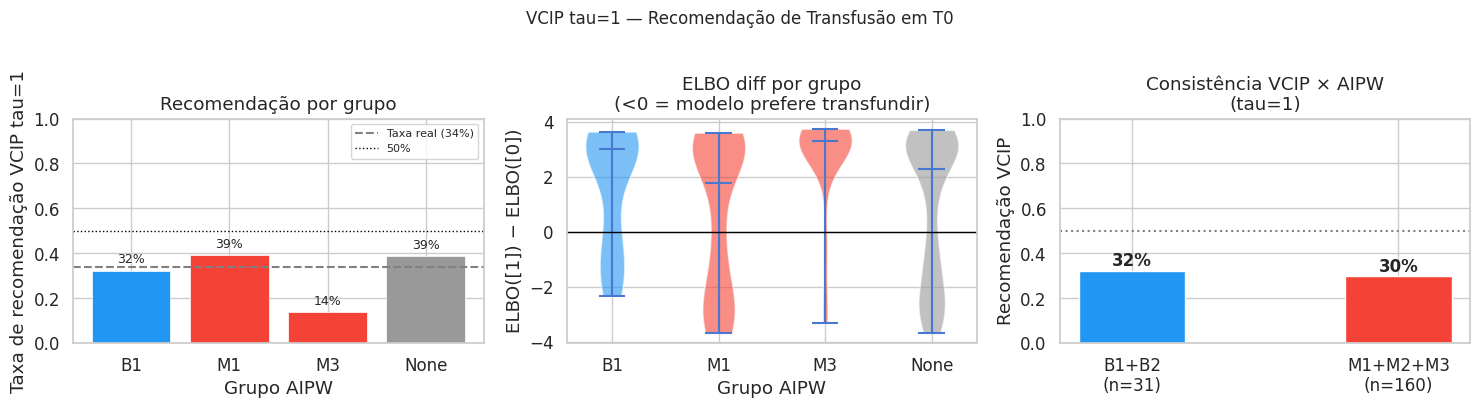

In [76]:
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

# ══════════════════════════════════════════════════════════════════════════════
# Seção 22D — Análise por grupo AIPW + hipótese de consistência
# ══════════════════════════════════════════════════════════════════════════════

if 'df1' not in dir():
    print('⚠  Rode a Seção 22C primeiro.')
else:
    grp_stats1 = (df1.groupby('group')
                    .agg(n=('orig_idx','count'),
                         real_transfusion_rate=('real_transfused','mean'),
                         vcip_rec_rate=('vcip_rec_transfusion','mean'),
                         elbo_diff_mean=('elbo_diff','mean'),
                         mortality_rate=('mortality','mean'))
                    .reset_index()
                    .sort_values('group'))

    print('═'*68)
    print('VCIP tau=1 — Taxa de Recomendação por Grupo AIPW')
    print('  elbo_diff = ELBO([1]) − ELBO([0]);  <0 = modelo prefere transfundir')
    print('═'*68)
    print(grp_stats1.to_string(index=False))
    print()

    # ── Hipótese de consistência B vs M ──────────────────────────────────────
    b_mask = df1['benefit_group'] == 1
    m_mask = (df1['benefit_group'] == 0) & (df1['group'] != 'None')
    rate_b = df1.loc[b_mask, 'vcip_rec_transfusion'].mean() if b_mask.sum() > 0 else float('nan')
    rate_m = df1.loc[m_mask, 'vcip_rec_transfusion'].mean() if m_mask.sum() > 0 else float('nan')

    print('─'*68)
    print(f'  Grupos B1+B2  (n={b_mask.sum():3d}) → recomendação VCIP: {rate_b:.1%}')
    print(f'  Grupos M1+M2+M3 (n={m_mask.sum():3d}) → recomendação VCIP: {rate_m:.1%}')

    if b_mask.sum() > 0 and m_mask.sum() > 0:
        ct = pd.crosstab(df1[b_mask | m_mask]['benefit_group'],
                         df1[b_mask | m_mask]['vcip_rec_transfusion'])
        ct = ct.reindex(index=[0,1], columns=[0,1], fill_value=0)
        if ct.values.sum() > 0:
            chi2, p, _, _ = chi2_contingency(ct)
            sig = '✓ CONSISTENTE (p<0.05)' if p < 0.05 else '~ não significativo'
            print(f'  Teste chi²: χ²={chi2:.3f}, p={p:.4f}  {sig}')

    # ── Visualização ─────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # 1. Taxa de recomendação por grupo
    grp_order = [g for g in ['B1','B2','M1','M2','M3','None']
                 if g in grp_stats1['group'].values]
    rates = [grp_stats1.loc[grp_stats1['group']==g, 'vcip_rec_rate'].values[0]
             for g in grp_order]
    colors = ['#2196F3' if g in ('B1','B2') else
              '#F44336' if g in ('M1','M2','M3') else '#999999'
              for g in grp_order]
    bars = axes[0].bar(grp_order, rates, color=colors, edgecolor='white', lw=0.5)
    axes[0].axhline(df1['real_transfused'].mean(), color='gray', ls='--', lw=1.5,
                    label=f"Taxa real ({df1['real_transfused'].mean():.0%})")
    axes[0].axhline(0.5, color='black', ls=':', lw=1, label='50%')
    for bar, rate in zip(bars, rates):
        axes[0].text(bar.get_x()+bar.get_width()/2, rate+0.02,
                     f'{rate:.0%}', ha='center', va='bottom', fontsize=9)
    axes[0].set(ylim=(0,1), xlabel='Grupo AIPW',
                ylabel='Taxa de recomendação VCIP tau=1',
                title='Recomendação por grupo')
    axes[0].legend(fontsize=8)

    # 2. Distribuição de elbo_diff por grupo
    data_vio = [df1.loc[df1['group']==g, 'elbo_diff'].values
                for g in grp_order if (df1['group']==g).sum() > 1]
    valid_grps = [g for g in grp_order if (df1['group']==g).sum() > 1]
    if data_vio:
        vp = axes[1].violinplot(data_vio, showmedians=True)
        axes[1].set_xticks(range(1, len(valid_grps)+1))
        axes[1].set_xticklabels(valid_grps)
        for body, g in zip(vp['bodies'], valid_grps):
            body.set_facecolor('#2196F3' if g in ('B1','B2')
                               else '#F44336' if g in ('M1','M2','M3')
                               else '#999999')
            body.set_alpha(0.6)
    axes[1].axhline(0, color='black', ls='-', lw=1)
    axes[1].set(xlabel='Grupo AIPW',
                ylabel='ELBO([1]) − ELBO([0])',
                title='ELBO diff por grupo\n(<0 = modelo prefere transfundir)')

    # 3. Concordância B vs M
    labels_bm = [f'B1+B2\n(n={b_mask.sum()})', f'M1+M2+M3\n(n={m_mask.sum()})']
    vals_bm   = [rate_b, rate_m]
    c_bm      = ['#2196F3','#F44336']
    axes[2].bar(labels_bm, vals_bm, color=c_bm, width=0.4, edgecolor='white')
    axes[2].axhline(0.5, color='gray', ls=':', lw=1.5)
    for i_, v in enumerate(vals_bm):
        if v == v:   # not NaN
            axes[2].text(i_, v+0.02, f'{v:.0%}', ha='center',
                         fontsize=12, fontweight='bold')
    axes[2].set(ylim=(0,1), ylabel='Recomendação VCIP',
                title='Consistência VCIP × AIPW\n(tau=1)')

    plt.suptitle('VCIP tau=1 — Recomendação de Transfusão em T0', y=1.02, fontsize=12)
    plt.tight_layout()
    plt.show()


---
## 22E. Características clínicas por recomendação VCIP

Comparação dos perfis clínicos de pacientes para os quais o VCIP recomendou transfusão (â*=[1]) vs. não recomendou (â*=[0]).
Inclui concordância com os estimandos AIPW.


══════════════════════════════════════════════════════════════════════════════
Características clínicas por decisão VCIP  (val + test, n=446)
  Contínuas: média ± dp  |  Binárias: %  |  Teste: t-Welch / χ²  |  * p<0,05
══════════════════════════════════════════════════════════════════════════════
                  Variável VCIP=0  (n=289) VCIP=1  (n=157) p-valor Sig
        Hemoglobina (g/dL)     9.15 ± 0.90     9.42 ± 1.27   0.019   *
          Lactato (mmol/L)     1.58 ± 0.89     1.74 ± 1.00   0.094    
                PAM (mmHg)    75.39 ± 9.12   72.74 ± 12.19   0.018   *
                SOFA Score     4.97 ± 2.58     4.91 ± 3.08   0.814    
        Creatinina (mg/dL)     1.23 ± 0.95     1.58 ± 1.69   0.017   *
       Plaquetas (×10³/µL)  195.73 ± 80.75  195.85 ± 95.14   0.990    
                  FC (bpm)   88.75 ± 11.02   88.78 ± 18.28   0.984    
                  SpO₂ (%)    97.57 ± 1.74    97.51 ± 2.20   0.766    
                  FR (rpm)    19.97 ± 3.80    20.57 ± 5.12   0.

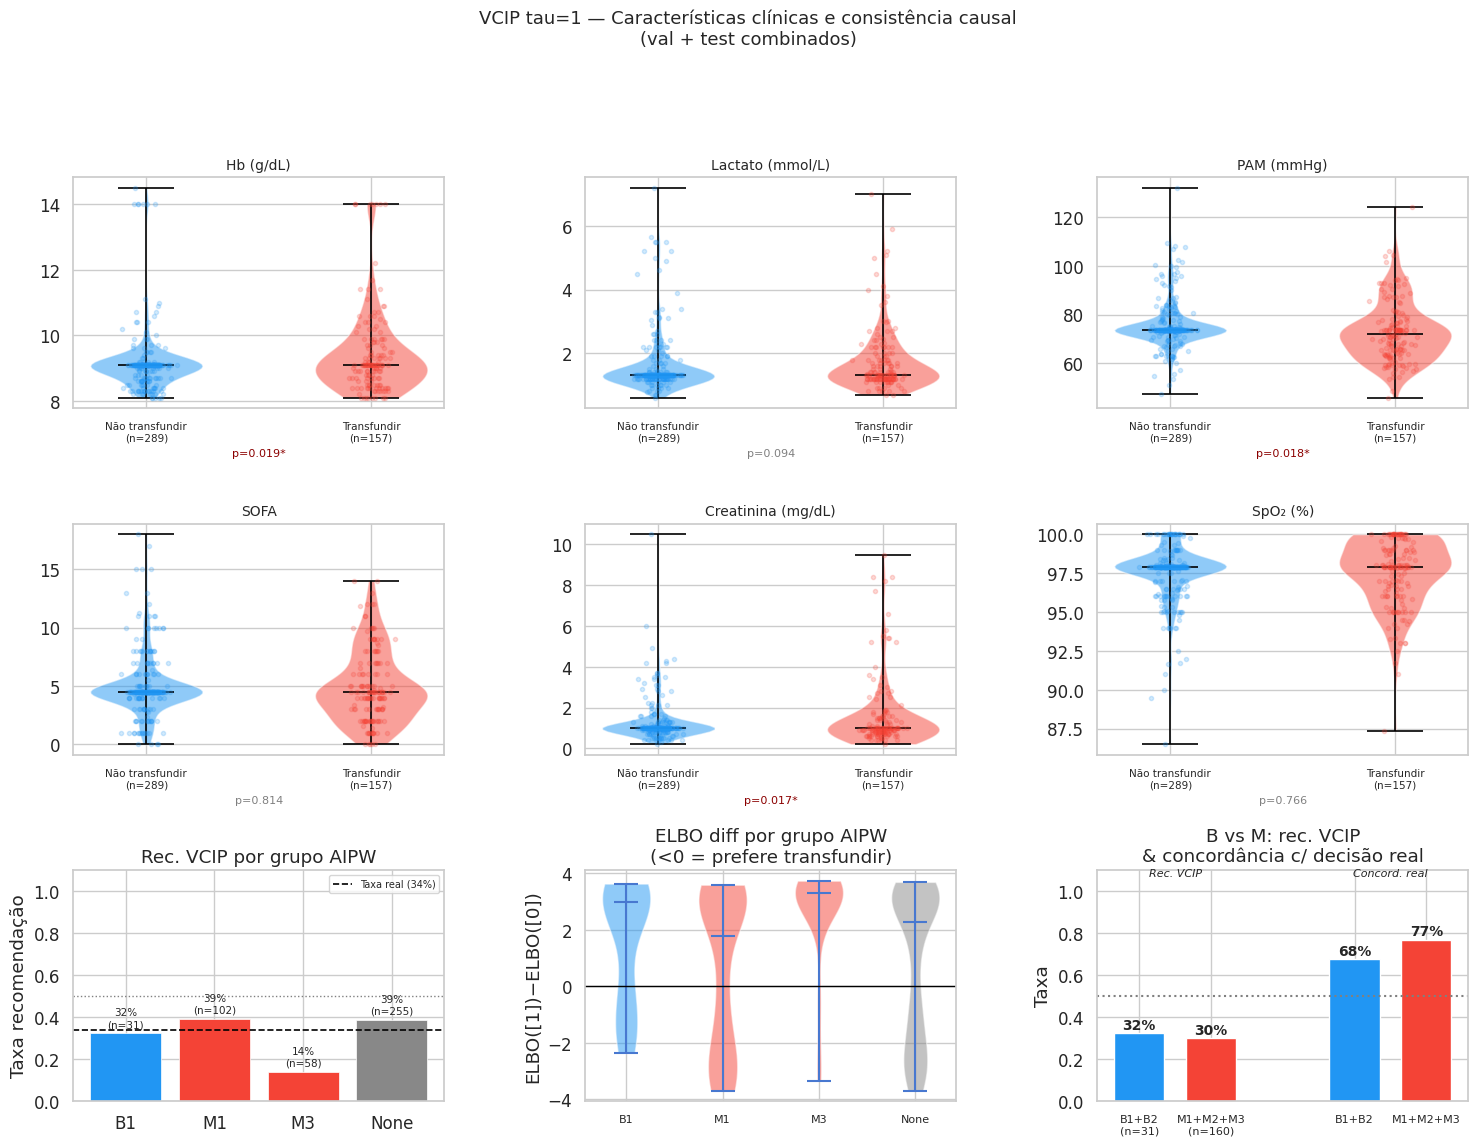

In [77]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import ttest_ind, chi2_contingency
import warnings
warnings.filterwarnings('ignore')

# ══════════════════════════════════════════════════════════════════════════════
# Seção 22E — Características clínicas por recomendação VCIP
# ══════════════════════════════════════════════════════════════════════════════

if 'df1' not in dir():
    print('⚠  Rode a Seção 22C primeiro.')
else:
    rec0 = df1[df1['vcip_rec_transfusion'] == 0]
    rec1 = df1[df1['vcip_rec_transfusion'] == 1]
    n0, n1 = len(rec0), len(rec1)

    # ── Tabela de características clínicas ────────────────────────────────────
    CHAR_VARS = [
        # (coluna,                  label,                      é contínua?)
        ('hemoglobin_last',        'Hemoglobina (g/dL)',         True),
        ('lactate_last',           'Lactato (mmol/L)',           True),
        ('mbp_last',               'PAM (mmHg)',                 True),
        ('sofa_last',              'SOFA Score',                 True),
        ('creatinine_last',        'Creatinina (mg/dL)',         True),
        ('platelets_last',         'Plaquetas (×10³/µL)',        True),
        ('heart_rate_last',        'FC (bpm)',                   True),
        ('spo2_last',              'SpO₂ (%)',                   True),
        ('resp_rate_last',         'FR (rpm)',                   True),
        ('age',                    'Idade (anos)',               True),
        ('bmi',                    'BMI (kg/m²)',                True),
        ('sex_male',               'Sexo masculino (%)',         False),
        ('any_vasopressor_last',   'Vasopressor em uso (%)',     False),
        ('ventilation_on_last',    'Ventilação mecânica (%)',    False),
        ('real_transfused',        'Transfundido realmente (%)', False),
        ('mortality',              'Mortalidade (%)',            False),
    ]

    rows = []
    for col, label, is_cont in CHAR_VARS:
        if col not in df1.columns:
            continue
        v0 = rec0[col].dropna()
        v1 = rec1[col].dropna()
        if len(v0) < 2 or len(v1) < 2:
            continue
        if is_cont:
            stat0 = f'{v0.mean():.2f} ± {v0.std():.2f}'
            stat1 = f'{v1.mean():.2f} ± {v1.std():.2f}'
            _, pval = ttest_ind(v0, v1, equal_var=False)
        else:
            stat0 = f'{v0.mean():.1%}'
            stat1 = f'{v1.mean():.1%}'
            ct = pd.crosstab(
                df1[col].map({0:'No',1:'Yes'}),
                df1['vcip_rec_transfusion'].map({0:'N',1:'S'})
            ).reindex(index=['No','Yes'], columns=['N','S'], fill_value=0)
            _, pval, _, _ = chi2_contingency(ct) if ct.values.min() > 0 else (None, float('nan'), None, None)
        rows.append({
            'Variável':              label,
            f'VCIP=0  (n={n0})':    stat0,
            f'VCIP=1  (n={n1})':    stat1,
            'p-valor':              f'{pval:.3f}' if pval == pval else '—',
            'Sig':                  ('*' if pval < 0.05 else '') if pval == pval else '',
        })

    char_df = pd.DataFrame(rows)
    print('═' * 78)
    print(f'Características clínicas por decisão VCIP  (val + test, n={len(df1)})')
    print('  Contínuas: média ± dp  |  Binárias: %  |  Teste: t-Welch / χ²  |  * p<0,05')
    print('═' * 78)
    print(char_df.to_string(index=False))

    # ── Concordância VCIP × AIPW ─────────────────────────────────────────────
    b_mask = df1['benefit_group'] == 1
    m_mask = (df1['benefit_group'] == 0) & (df1['group'] != 'None')
    rate_b = df1.loc[b_mask, 'vcip_rec_transfusion'].mean() if b_mask.sum() > 0 else float('nan')
    rate_m = df1.loc[m_mask, 'vcip_rec_transfusion'].mean() if m_mask.sum() > 0 else float('nan')
    print()
    print('─' * 78)
    print('Consistência VCIP × AIPW:')
    print(f'  B1+B2    (n={b_mask.sum():3d}) → VCIP recomenda transfusão: {rate_b:.1%}')
    print(f'  M1+M2+M3 (n={m_mask.sum():3d}) → VCIP recomenda transfusão: {rate_m:.1%}')
    if b_mask.sum() > 0 and m_mask.sum() > 0:
        ct_bm = pd.crosstab(df1[b_mask | m_mask]['benefit_group'],
                            df1[b_mask | m_mask]['vcip_rec_transfusion'])
        ct_bm = ct_bm.reindex(index=[0,1], columns=[0,1], fill_value=0)
        if ct_bm.values.sum() > 0:
            chi2_v, p_bm, _, _ = chi2_contingency(ct_bm)
            sig = '✓ CONSISTENTE (p<0,05)' if p_bm < 0.05 else '~ não significativo'
            print(f'  χ²={chi2_v:.3f}, p={p_bm:.4f}  {sig}')

    # ── Concordância VCIP × decisão real por grupo ────────────────────────────
    print()
    print('Concordância VCIP × decisão real por grupo AIPW:')
    grp_order_all = ['B1','B2','M1','M2','M3','None']
    for g in grp_order_all:
        gdf = df1[df1['group'] == g]
        if len(gdf) == 0:
            continue
        agree = (gdf['vcip_rec_transfusion'] == gdf['real_transfused']).mean()
        rec_r = gdf['vcip_rec_transfusion'].mean()
        real_r = gdf['real_transfused'].mean()
        print(f'  {g:<5}  n={len(gdf):3d}  rec_VCIP={rec_r:.1%}  real={real_r:.1%}  concordância={agree:.1%}')

    # ── Plots ─────────────────────────────────────────────────────────────────
    key_vitals = [
        ('hemoglobin_last',  'Hb (g/dL)'),
        ('lactate_last',     'Lactato (mmol/L)'),
        ('mbp_last',         'PAM (mmHg)'),
        ('sofa_last',        'SOFA'),
        ('creatinine_last',  'Creatinina (mg/dL)'),
        ('spo2_last',        'SpO₂ (%)'),
    ]

    fig = plt.figure(figsize=(18, 12))
    gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.50, wspace=0.38)
    colors_rec = {0: '#2196F3', 1: '#F44336'}

    # Violin + jitter por vital chave
    for k, (col, lbl) in enumerate(key_vitals):
        if col not in df1.columns:
            continue
        ax = fig.add_subplot(gs[k // 3, k % 3])
        data_v = [rec0[col].dropna().values, rec1[col].dropna().values]
        if all(len(d) > 1 for d in data_v):
            vp = ax.violinplot(data_v, showmedians=True, positions=[0, 1])
            for body, c in zip(vp['bodies'], [colors_rec[0], colors_rec[1]]):
                body.set_facecolor(c); body.set_alpha(0.50)
            for part in ('cmedians', 'cmins', 'cmaxes', 'cbars'):
                if part in vp:
                    vp[part].set_color('black'); vp[part].set_linewidth(1.2)
        for pos, grp_df, c in [(0, rec0, colors_rec[0]), (1, rec1, colors_rec[1])]:
            vals   = grp_df[col].dropna().values
            jitter = np.random.normal(0, 0.04, size=len(vals))
            ax.scatter(pos + jitter, vals, alpha=0.20, s=9, color=c, zorder=3)
        ax.set_xticks([0, 1])
        ax.set_xticklabels([f'Não transfundir\n(n={n0})', f'Transfundir\n(n={n1})'], fontsize=7.5)
        ax.set_title(lbl, fontsize=10)
        v0_v = rec0[col].dropna().values
        v1_v = rec1[col].dropna().values
        if len(v0_v) > 1 and len(v1_v) > 1:
            _, pv = ttest_ind(v0_v, v1_v, equal_var=False)
            pstr  = f'p={pv:.3f}{"*" if pv < 0.05 else ""}'
            ax.set_xlabel(pstr, fontsize=8, color='darkred' if pv < 0.05 else 'gray')

    # Taxa de recomendação VCIP por grupo AIPW
    ax_g = fig.add_subplot(gs[2, 0])
    grp_order = [g for g in grp_order_all if g in df1['group'].values]
    g_rates = [df1.loc[df1['group']==g, 'vcip_rec_transfusion'].mean() for g in grp_order]
    g_ns    = [df1.loc[df1['group']==g].shape[0] for g in grp_order]
    g_cols  = ['#2196F3' if g in ('B1','B2') else '#F44336' if g in ('M1','M2','M3') else '#888'
               for g in grp_order]
    bars = ax_g.bar(grp_order, g_rates, color=g_cols, edgecolor='white', lw=0.5)
    ax_g.axhline(df1['real_transfused'].mean(), color='black', ls='--', lw=1.2,
                 label=f'Taxa real ({df1["real_transfused"].mean():.0%})')
    ax_g.axhline(0.5, color='gray', ls=':', lw=1)
    for bar, r, n_ in zip(bars, g_rates, g_ns):
        ax_g.text(bar.get_x()+bar.get_width()/2, r+0.02, f'{r:.0%}\n(n={n_})',
                  ha='center', va='bottom', fontsize=7.5)
    ax_g.set(ylim=(0,1.1), title='Rec. VCIP por grupo AIPW', ylabel='Taxa recomendação')
    ax_g.legend(fontsize=7)

    # ELBO diff por grupo AIPW
    ax_e = fig.add_subplot(gs[2, 1])
    data_e = [df1.loc[df1['group']==g, 'elbo_diff'].values
              for g in grp_order if (df1['group']==g).sum() > 1]
    valid_eg = [g for g in grp_order if (df1['group']==g).sum() > 1]
    if data_e:
        vp2 = ax_e.violinplot(data_e, showmedians=True)
        ax_e.set_xticks(range(1, len(valid_eg)+1))
        ax_e.set_xticklabels(valid_eg, fontsize=8)
        for body, g in zip(vp2['bodies'], valid_eg):
            body.set_facecolor('#2196F3' if g in ('B1','B2')
                               else '#F44336' if g in ('M1','M2','M3') else '#888')
            body.set_alpha(0.50)
    ax_e.axhline(0, color='black', ls='-', lw=1)
    ax_e.set(title='ELBO diff por grupo AIPW\n(<0 = prefere transfundir)',
             ylabel='ELBO([1])−ELBO([0])')

    # B vs M: rec. rate + concordância com decisão real
    ax_bm = fig.add_subplot(gs[2, 2])
    agree_b = (df1.loc[b_mask, 'vcip_rec_transfusion'] == df1.loc[b_mask, 'real_transfused']).mean() if b_mask.sum() > 0 else float('nan')
    agree_m = (df1.loc[m_mask, 'vcip_rec_transfusion'] == df1.loc[m_mask, 'real_transfused']).mean() if m_mask.sum() > 0 else float('nan')
    x_pos   = [0, 1, 3, 4]
    heights = [rate_b, rate_m, agree_b, agree_m]
    bar_cols= ['#2196F3','#F44336','#2196F3','#F44336']
    x_lbls  = [f'B1+B2\n(n={b_mask.sum()})', f'M1+M2+M3\n(n={m_mask.sum()})',
               f'B1+B2', f'M1+M2+M3']
    bars = ax_bm.bar(x_pos, heights, color=bar_cols, edgecolor='white', width=0.7)
    for bar, h in zip(bars, heights):
        if h == h:
            ax_bm.text(bar.get_x()+bar.get_width()/2, h+0.02,
                       f'{h:.0%}', ha='center', fontsize=10, fontweight='bold')
    ax_bm.axhline(0.5, color='gray', ls=':', lw=1.5)
    ax_bm.set_xticks(x_pos)
    ax_bm.set_xticklabels(x_lbls, fontsize=8)
    ax_bm.set(ylim=(0, 1.1), ylabel='Taxa')
    ax_bm.text(0.5, 1.07, 'Rec. VCIP', ha='center', transform=ax_bm.transData,
               fontsize=8, style='italic')
    ax_bm.text(3.5, 1.07, 'Concord. real', ha='center', transform=ax_bm.transData,
               fontsize=8, style='italic')
    ax_bm.set_title('B vs M: rec. VCIP\n& concordância c/ decisão real')

    plt.suptitle('VCIP tau=1 — Características clínicas e consistência causal\n(val + test combinados)',
                 y=1.02, fontsize=13)
    plt.tight_layout()
    plt.show()
